In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import plotly.graph_objects as go
import seaborn as sns
import h5py
from collections import Counter
import scipy.sparse as sp
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patheffects as path_effects
# from matplotlib_venn import venn3
# import pyranges as pr
import yaml
import time
from itertools import combinations
import gget
from scipy import sparse

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

sc.settings.verbosity = 3

# Load gene resources

In [2]:
%%time 
# === Load and filter GTF ===
gpath = "/scratch/indikar_root/indikar1/shared_data/HYB/resources/refdata-gex-GRCh38-2024-A_genes.csv.gz"

gtf = pd.read_csv(gpath)

exons = gtf[gtf['Feature'] == 'exon']
print(f"{exons.shape=}")
exons.head()

exons.shape=(1586950, 27)
CPU times: user 11.6 s, sys: 1.85 s, total: 13.4 s
Wall time: 13.6 s


,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,exon_version,hgnc_id,havana_gene,protein_id,ccdsid
2,GL000009.2,ENSEMBL,exon,56139,58376,.,-,.,ENSG00000278704,1,...,ENST00000618686,NaN,NaN,1.0,ENSE00003753029,1.0,NaN,NaN,ENSP00000484918.1,NaN
10,GL000194.1,ENSEMBL,exon,114985,115018,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,1.0,ENSE00002299440,2.0,NaN,NaN,ENSP00000483280.1,NaN
11,GL000194.1,ENSEMBL,exon,112791,112850,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,2.0,ENSE00003739295,1.0,NaN,NaN,ENSP00000483280.1,NaN
12,GL000194.1,ENSEMBL,exon,53589,55676,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,3.0,ENSE00003723764,1.0,NaN,NaN,ENSP00000483280.1,NaN
22,GL000194.1,ENSEMBL,exon,114985,115055,.,-,.,ENSG00000274847,1,...,MAFIP-201,1.0,NaN,1.0,ENSE00003736481,1.0,HGNC:31102,NaN,ENSP00000478910.1,NaN


In [4]:
fpath = "../../resources/isoform_map.csv.gz"

idf = pd.read_csv(fpath)
print(f"{idf.shape=}")

idf['uniprot'] = np.where(idf['UniProtKB/TrEMBL ID'].isna(), idf['UniProtKB/Swiss-Prot ID'], idf['UniProtKB/TrEMBL ID'])

transcript_2_uniprot = dict(zip(idf['Transcript name'].values, idf['uniprot'].values))

idf.head()

idf.shape=(110149, 11)


,Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,Protein stable ID,Protein stable ID version,Transcript length (including UTRs and CDS),Transcript name,Gene name,UniProtKB/Swiss-Prot ID,UniProtKB/TrEMBL ID,uniprot
0,ENSG00000198888,ENSG00000198888.2,ENST00000361390,ENST00000361390.2,ENSP00000354687,ENSP00000354687.2,956,MT-ND1-201,MT-ND1,P03886,U5Z754,U5Z754
1,ENSG00000198763,ENSG00000198763.3,ENST00000361453,ENST00000361453.3,ENSP00000355046,ENSP00000355046.4,1042,MT-ND2-201,MT-ND2,P03891,Q7GXY9,Q7GXY9
2,ENSG00000198804,ENSG00000198804.2,ENST00000361624,ENST00000361624.2,ENSP00000354499,ENSP00000354499.2,1542,MT-CO1-201,MT-CO1,P00395,U5YWV7,U5YWV7
3,ENSG00000198712,ENSG00000198712.1,ENST00000361739,ENST00000361739.1,ENSP00000354876,ENSP00000354876.1,684,MT-CO2-201,MT-CO2,P00403,U5Z487,U5Z487
4,ENSG00000228253,ENSG00000228253.1,ENST00000361851,ENST00000361851.1,ENSP00000355265,ENSP00000355265.1,207,MT-ATP8-201,MT-ATP8,P03928,U5YV54,U5YV54


In [5]:
idf['uniprot'].nunique()

73747

In [6]:
upath = "/scratch/indikar_root/indikar1/jrcwycy/hsc_temp/HUMAN_9606_idmapping_selected.tab.gz"

columns = [
    'UniProtKB-AC',
    'UniProtKB-ID',
    'GeneID (EntrezGene)',
    'RefSeq',
    'GI',
    'PDB',
    'GO',
    'UniRef100',
    'UniRef90',
    'UniRef50',
    'UniParc',
    'PIR',
    'NCBI-taxon',
    'MIM',
    'UniGene',
    'PubMed',
    'EMBL',
    'EMBL-CDS',
    'Ensembl',
    'Ensembl_TRS',
    'Ensembl_PRO',
    'Additional PubMed',
]

udf = pd.read_csv(
    upath, 
    sep='\t',
    header=None,
    low_memory=False,
    names=columns,
)

keep_columns = [
    'UniProtKB-AC',
    'UniProtKB-ID',
    # 'Ensembl',
    'Ensembl_TRS',
]

udf = udf[keep_columns]
udf = udf.assign(Ensembl_TRS=udf['Ensembl_TRS'].str.split(';')).explode('Ensembl_TRS')
udf['transcript_id'] = udf['Ensembl_TRS'].apply(lambda x: str(x).split(".")[0])
udf = udf.rename(columns={'UniProtKB-AC': 'uniprot'})

transcript_map = dict(zip(udf['transcript_id'].values, udf['uniprot'].values))

udf.head()

,uniprot,UniProtKB-ID,Ensembl_TRS,transcript_id
0,P31946,1433B_HUMAN,ENST00000353703.9,ENST00000353703
0,P31946,1433B_HUMAN,ENST00000372839.7,ENST00000372839
1,P62258,1433E_HUMAN,ENST00000264335.13,ENST00000264335
1,P62258,1433E_HUMAN,ENST00000571732.5,ENST00000571732
1,P62258,1433E_HUMAN,ENST00000616643.3,ENST00000616643


In [7]:
gtf_sub = gtf[['transcript_id', 'transcript_name']].drop_duplicates()
gtf_sub = gtf_sub.dropna()
print(gtf_sub.shape)
gtf_sub.head()

(226005, 2)


,transcript_id,transcript_name
1,ENST00000618686,ENST00000618686
9,ENST00000613230,ENST00000613230
21,ENST00000400754,MAFIP-201
35,ENST00000612465,ENST00000612465
45,ENST00000616049,ENST00000616049


In [8]:
udf1 = pd.merge(udf, gtf_sub, how='left', on='transcript_id')
print(udf1.shape)

udf1 = udf1.dropna(subset='transcript_name')

print(udf1.shape)
udf1.head()

(246523, 5)
(78415, 5)


,uniprot,UniProtKB-ID,Ensembl_TRS,transcript_id,transcript_name
0,P31946,1433B_HUMAN,ENST00000353703.9,ENST00000353703,YWHAB-201
2,P62258,1433E_HUMAN,ENST00000264335.13,ENST00000264335,YWHAE-201
6,Q04917,1433F_HUMAN,ENST00000248975.6,ENST00000248975,YWHAH-201
7,P61981,1433G_HUMAN,ENST00000307630.5,ENST00000307630,YWHAG-201
8,P31947,1433S_HUMAN,ENST00000339276.6,ENST00000339276,SFN-201


In [9]:
print(udf['uniprot'].nunique())
print(udf1['uniprot'].nunique())

205003
78415


In [10]:
transcript_map = dict(zip(udf1['transcript_name'].values, udf1['uniprot'].values))

In [11]:
# fpath = "../../resources/allTFs_hg38.txt"
# tf_list = [x.strip() for x in open(fpath)]
# tf_list[:10]
# TFs
fpath = "../../resources/HumanTF_v_1.01.csv"

tdf = pd.read_csv(fpath)

tdf = tdf[['HGNC symbol', 'Is TF?']]
tdf = tdf.rename(columns={'HGNC symbol': 'gene_name', 'Is TF?': 'is_tf'})
tdf = tdf[tdf['is_tf'] == 'Yes']
tdf = tdf.drop_duplicates(subset='gene_name')
display(tdf.head())

# extract unique TFs
tf_list = tdf['gene_name'].unique()

print(len(tf_list))

,gene_name,is_tf
0,TFAP2A,Yes
1,TFAP2B,Yes
2,TFAP2C,Yes
3,TFAP2D,Yes
4,TFAP2E,Yes


1639


# Load gene data

In [12]:
%%time
# path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_merged_gene_data.h5ad"
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
gdata = sc.read_h5ad(path)
gdata

CPU times: user 482 ms, sys: 1.53 s, total: 2.02 s
Wall time: 6.77 s


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

# Load isoform data

In [14]:
%%time

path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/isoforms.h5ad"
adata = sc.read_h5ad(path)
adata.var.set_index('transcript_name', inplace=True)
print(adata)
adata.var.head()

AnnData object with n_obs × n_vars = 19858 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB'
CPU times: user 300 ms, sys: 463 ms, total: 762 ms
Wall time: 1.96 s


,gene_id,gene_name,gene_type,transcript_type,Chromosome,Start,End,transcript_id,UniProtKB
transcript_name,,,,,,,,,
ARF5-201,ENSG00000004059,ARF5,protein_coding,protein_coding,chr7,127588410,127591700,ENST00000000233,P84085
M6PR-201,ENSG00000003056,M6PR,protein_coding,protein_coding,chr12,8940360,8949645,ENST00000000412,P20645
ESRRA-201,ENSG00000173153,ESRRA,protein_coding,protein_coding,chr11,64305523,64316743,ENST00000000442,P11474
FKBP4-201,ENSG00000004478,FKBP4,protein_coding,protein_coding,chr12,2794969,2805423,ENST00000001008,Q02790
CYP26B1-201,ENSG00000003137,CYP26B1,protein_coding,protein_coding,chr2,72129237,72147862,ENST00000001146,Q9NR63


In [15]:
%%time

print(f"Initial number of cells in adata: {adata.n_obs}")
print(f"Number of cells in gdata: {gdata.n_obs}")

# Subset adata to those present in bdata
cells_to_keep = adata.obs_names.isin(gdata.obs_names)
print(f"Number of cells in adata after filtering by gdata: {cells_to_keep.sum()}")

adata = adata[cells_to_keep, :].copy()
print(f"Final number of cells in adata: {adata.n_obs}")

# Sort adata and bdata to the same order (shared cells only)
shared_cells = gdata.obs_names.intersection(adata.obs_names)
print(f"Number of shared cells: {len(shared_cells)}")

# Sort both AnnData objects
adata = adata[shared_cells, :].copy()
gdata_sorted = gdata[shared_cells, :].copy()

# Assert same order
assert all(adata.obs_names == gdata_sorted.obs_names), "Cell ordering does not match!"
print("Cell ordering is identical between adata and bdata (shared cells).")
adata

Initial number of cells in adata: 19858
Number of cells in gdata: 16296
Number of cells in adata after filtering by gdata: 16296
Final number of cells in adata: 16296
Number of shared cells: 16296
Cell ordering is identical between adata and bdata (shared cells).
CPU times: user 1.52 s, sys: 2.75 s, total: 4.27 s
Wall time: 4.32 s


AnnData object with n_obs × n_vars = 16296 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB'

In [16]:
adata

AnnData object with n_obs × n_vars = 16296 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB'

Before merge: adata.obs columns = ['dataset', 'n_reads', 'n_transcripts']
After merge: adata.obs columns = ['dataset', 'n_reads', 'n_transcripts', 'leiden_split', 'pooled_condition', 'phase', 'dataset_gdata']
AnnData object with n_obs × n_vars = 16296 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts', 'leiden_split', 'pooled_condition', 'phase', 'dataset_gdata'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB'
    uns: 'leiden_split_colors', 'dataset_colors', 'pooled_condition_colors', 'umap'
    obsm: 'X_umap'


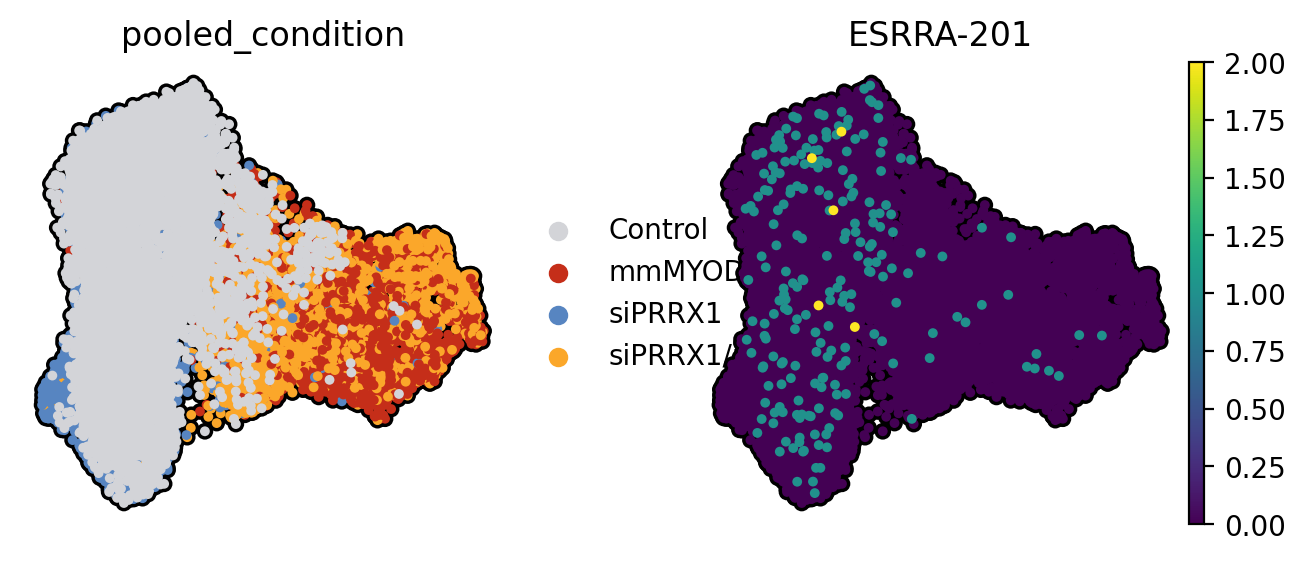

CPU times: user 914 ms, sys: 34.4 ms, total: 949 ms
Wall time: 1.05 s


In [17]:
%%time

obs_columns = [
    'leiden_split',
    'pooled_condition',
    'phase',
    'dataset',
]

print(f"Before merge: adata.obs columns = {list(adata.obs.columns)}")

# Subset bdata.obs to the needed columns
df_merge = gdata.obs[obs_columns].copy()
df_merge.index.name = "cell"

# Merge by index (obs_names)
adata.obs = adata.obs.merge(df_merge, left_index=True, right_index=True, suffixes=('', '_gdata'))

print(f"After merge: adata.obs columns = {list(adata.obs.columns)}")

# Add uns
adata.uns['leiden_split_colors'] = gdata.uns['leiden_split_colors'].copy()
adata.uns['dataset_colors'] = gdata.uns['dataset_colors'].copy()
adata.uns['pooled_condition_colors'] = gdata.uns['pooled_condition_colors'].copy()

# Merge embeddings
adata.obsm['X_umap'] = gdata.obsm['X_umap'].copy()
adata.uns['umap'] = gdata.uns['umap'].copy()

print(adata)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.umap(
    adata,
    ncols=2,
    sort_order=True,
    color=['pooled_condition', 'ESRRA-201'],
    size=50,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
)

In [18]:
sc.pp.filter_genes(adata, min_counts=20)

adata.layers['counts'] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.layers['log_norm'] = adata.X.copy()
adata

filtered out 31726 genes that are detected in less than 20 counts
normalizing counts per cell
    finished (0:00:01)


AnnData object with n_obs × n_vars = 16296 × 57844
    obs: 'dataset', 'n_reads', 'n_transcripts', 'leiden_split', 'pooled_condition', 'phase', 'dataset_gdata'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB', 'n_counts'
    uns: 'leiden_split_colors', 'dataset_colors', 'pooled_condition_colors', 'umap', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', 'log_norm'

In [19]:
adata.obs.head()

,dataset,n_reads,n_transcripts,leiden_split,pooled_condition,phase,dataset_gdata
AAACCAAAGCAACTGC_hybrid,Hybrid,10383,3090,H1,siPRRX1/mmMYOD1,G2M,Hybrid
AAACCAAAGTAGGGCA_hybrid,Hybrid,5458,2211,M1,mmMYOD1,S,Hybrid
AAACCAAAGTCTAGGC_hybrid,Hybrid,15520,4099,H1,siPRRX1/mmMYOD1,G1,Hybrid
AAACCATTCACGTAAT_hybrid,Hybrid,5523,2053,P1,siPRRX1,G2M,Hybrid
AAACCATTCAGGCAGA_hybrid,Hybrid,11290,2922,P1,siPRRX1,G2M,Hybrid


In [20]:
adata.var.head()

,gene_id,gene_name,gene_type,transcript_type,Chromosome,Start,End,transcript_id,UniProtKB,n_counts
transcript_name,,,,,,,,,,
ARF5-201,ENSG00000004059,ARF5,protein_coding,protein_coding,chr7,127588410,127591700,ENST00000000233,P84085,15066
M6PR-201,ENSG00000003056,M6PR,protein_coding,protein_coding,chr12,8940360,8949645,ENST00000000412,P20645,4571
ESRRA-201,ENSG00000173153,ESRRA,protein_coding,protein_coding,chr11,64305523,64316743,ENST00000000442,P11474,223
FKBP4-201,ENSG00000004478,FKBP4,protein_coding,protein_coding,chr12,2794969,2805423,ENST00000001008,Q02790,2893
NDUFAF7-201,ENSG00000003509,NDUFAF7,protein_coding,protein_coding,chr2,37231657,37249160,ENST00000002125,Q7L592,488


In [21]:
df = adata.var.copy()

df.head()

df[df['gene_name'] == 'PRRX1']

,gene_id,gene_name,gene_type,transcript_type,Chromosome,Start,End,transcript_id,UniProtKB,n_counts
transcript_name,,,,,,,,,,
PRRX1-201,ENSG00000116132,PRRX1,protein_coding,protein_coding,chr1,170664130,170739421,ENST00000239461,P54821,933
PRRX1-202,ENSG00000116132,PRRX1,protein_coding,protein_coding,chr1,170663133,170736508,ENST00000367760,NaN,5717
PRRX1-204,ENSG00000116132,PRRX1,protein_coding,protein_coding_CDS_not_defined,chr1,170730205,170736233,ENST00000485529,NaN,25
PRRX1-207,ENSG00000116132,PRRX1,protein_coding,protein_coding,chr1,170663936,170729021,ENST00000497230,G3V2N3,2111
PRRX1-208,ENSG00000116132,PRRX1,protein_coding,protein_coding_CDS_not_defined,chr1,170662727,170719903,ENST00000553786,NaN,370


# Isoform table

In [22]:
%%time 

adata.X = adata.layers['counts'].copy()

aggdata = sc.get.aggregate(
    adata, 
    # by='pooled_condition',
    by='leiden_split',
    func='sum',
    axis=0,
)

aggdata.X = aggdata.layers['sum'].copy()

sc.pp.normalize_total(aggdata, target_sum=1e4)
sc.pp.log1p(aggdata)

aggdata.layers['log_norm'] = aggdata.X.copy()

aggdata


df = aggdata.to_df(layer='sum').T
df['total_transcript'] = df.sum(axis=1)

df = pd.merge(
    df, adata.var[['gene_name', 'gene_type', 'transcript_type']],#, 'transcript_name']],
    how='left',
    left_index=True,
    right_index=True,
)

df = df.reset_index(names='transcript_name')
df = df.sort_values(by=['gene_name', 'transcript_name'])
df = df.reset_index(drop=True)
df['is_tf'] = df['gene_name'].isin(tf_list)
df['uniprot'] = df['transcript_name'].map(transcript_map)
# df['uniprot'] = df['transcript_name'].map(transcript_2_uniprot)
print(f"{df.shape=}")
df.head()

normalizing counts per cell
    finished (0:00:00)
df.shape=(57844, 19)
CPU times: user 452 ms, sys: 367 ms, total: 819 ms
Wall time: 834 ms


,transcript_name,C1,C2,C3,H1,H2,H3,M1,M2,M3,P1,P2,P3,total_transcript,gene_name,gene_type,transcript_type,is_tf,uniprot
0,A1BG-203,5.0,4.0,0.0,5.0,7.0,1.0,3.0,2.0,1.0,4.0,9.0,3.0,44.0,A1BG,protein_coding,protein_coding_CDS_not_defined,False,NaN
1,A1BG-204,2500.0,3628.0,38.0,657.0,812.0,180.0,360.0,534.0,100.0,936.0,1415.0,382.0,11542.0,A1BG,protein_coding,retained_intron,False,NaN
2,A1BG-AS1-202,16.0,18.0,0.0,12.0,2.0,3.0,2.0,1.0,1.0,6.0,13.0,3.0,77.0,A1BG-AS1,lncRNA,lncRNA,False,NaN
3,A1BG-AS1-203,7.0,12.0,0.0,5.0,6.0,1.0,1.0,0.0,1.0,3.0,5.0,0.0,41.0,A1BG-AS1,lncRNA,lncRNA,False,NaN
4,A1BG-AS1-204,52.0,41.0,3.0,23.0,33.0,11.0,12.0,19.0,10.0,20.0,35.0,9.0,268.0,A1BG-AS1,lncRNA,lncRNA,False,NaN


In [23]:
df['uniprot'].nunique()

23040

In [ ]:
# %%time 
# adata.X = adata.layers['log_norm'].copy()
# # rsc.get.anndata_to_GPU(adata)
# print(f"{type(adata.X)=}")

# aggdata = rsc.get.aggregate(
#     adata, 
#     by='pooled_condition',
#     func='sum',
#     axis=0,
# )

# # rsc.get.anndata_to_CPU(aggdata, convert_all=True,)

# aggdata

# df = aggdata.to_df(layer='sum')
# df = df.T
# df['total_transcript'] = df.sum(axis=1)

# df = pd.merge(
#     df, adata.var[['gene_name', 'gene_type', 'transcript_type']],#, 'transcript_name']],
#     how='left',
#     left_index=True,
#     right_index=True,
# )
# df = df.reset_index(names='transcript_name')
# df = df.sort_values(by=['gene_name', 'transcript_name'])
# df = df.reset_index(drop=True)
# df['is_tf'] = df['gene_name'].isin(tf_list)
# df['uniprot'] = df['transcript_name'].map(transcript_2_uniprot)
# print(f"{df.shape=}")
# df.head()

# Add splicing events

In [25]:
fpath = "../../resources/AS_events.csv.gz"

asdf = pd.read_csv(fpath)
asdf = asdf[asdf['gene_name'].notna()]
asdf = asdf.drop(columns=['gene_id', 'transcript_id', 'gene_name'])
asdf.head()

df = pd.merge(
    df, asdf,
    how='left',
    on='transcript_name',
)
print(f"{df.shape=}")
print()

df.head()

df.shape=(57844, 27)



,transcript_name,C1,C2,C3,H1,H2,H3,M1,M2,M3,...,is_tf,uniprot,A3,A5,AF,AL,MX,RI,SE,num_events
0,A1BG-203,5.0,4.0,0.0,5.0,7.0,1.0,3.0,2.0,1.0,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A1BG-204,2500.0,3628.0,38.0,657.0,812.0,180.0,360.0,534.0,100.0,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A1BG-AS1-202,16.0,18.0,0.0,12.0,2.0,3.0,2.0,1.0,1.0,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A1BG-AS1-203,7.0,12.0,0.0,5.0,6.0,1.0,1.0,0.0,1.0,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A1BG-AS1-204,52.0,41.0,3.0,23.0,33.0,11.0,12.0,19.0,10.0,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Add metadata

In [26]:
clusters = sorted(adata.obs['leiden_split'].unique())

print(clusters)

['C1', 'C2', 'C3', 'H1', 'H2', 'H3', 'M1', 'M2', 'M3', 'P1', 'P2', 'P3']


In [27]:
sorted(adata.obs['pooled_condition'].unique())

['Control', 'mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']

In [28]:
%%time
pdf = df.copy()

# count the number of isoforms per gene
pdf['n_isoforms'] = pdf.groupby('gene_name', observed=True)['transcript_name'].transform('nunique')
pdf['n_protiens'] = pdf.groupby('gene_name', observed=True)['uniprot'].transform('nunique')


# clusters = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']
# clusters = ['Control', 'mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']

clusters = sorted(adata.obs['leiden_split'].unique())

# add grouped expression counts
grouped = pdf.groupby('gene_name', observed=True)[clusters].sum()
sum_columns  = [f'{col}_sum' for col in grouped.columns]
grouped.columns = sum_columns
pdf = pdf.merge(grouped, on='gene_name', how='left')

pdf['total_gene'] = pdf[sum_columns].sum(axis=1)

# add percentages
for col in clusters:
    sum_col = f'{col}_sum'
    pct_col = f'{col}_pct'
    pdf[pct_col] = pdf[col] / pdf[sum_col]

pdf.head()
    
# print(pdf[['gene_name', 'transcript_name', 'Control_pct', 'mmMYOD1_pct', 'siPRRX1_pct']].head().to_string())

CPU times: user 101 ms, sys: 1.05 ms, total: 102 ms
Wall time: 113 ms


,transcript_name,C1,C2,C3,H1,H2,H3,M1,M2,M3,...,C3_pct,H1_pct,H2_pct,H3_pct,M1_pct,M2_pct,M3_pct,P1_pct,P2_pct,P3_pct
0,A1BG-203,5.0,4.0,0.0,5.0,7.0,1.0,3.0,2.0,1.0,...,0.0,0.007553,0.008547,0.005525,0.008264,0.003731,0.009901,0.004255,0.006320,0.007792
1,A1BG-204,2500.0,3628.0,38.0,657.0,812.0,180.0,360.0,534.0,100.0,...,1.0,0.992447,0.991453,0.994475,0.991736,0.996269,0.990099,0.995745,0.993680,0.992208
2,A1BG-AS1-202,16.0,18.0,0.0,12.0,2.0,3.0,2.0,1.0,1.0,...,0.0,0.122449,0.022472,0.111111,0.045455,0.017857,0.047619,0.080000,0.093525,0.096774
3,A1BG-AS1-203,7.0,12.0,0.0,5.0,6.0,1.0,1.0,0.0,1.0,...,0.0,0.051020,0.067416,0.037037,0.022727,0.000000,0.047619,0.040000,0.035971,0.000000
4,A1BG-AS1-204,52.0,41.0,3.0,23.0,33.0,11.0,12.0,19.0,10.0,...,0.6,0.234694,0.370787,0.407407,0.272727,0.339286,0.476190,0.266667,0.251799,0.290323


In [29]:
columns_init = [
    'gene_name', 'transcript_name',
    'transcript_type', 'uniprot',
     'A3', 'A5', 'AF', 'AL', 'MX', 'RI', 'SE',
]

columns = columns_init + clusters

columns

['gene_name',
 'transcript_name',
 'transcript_type',
 'uniprot',
 'A3',
 'A5',
 'AF',
 'AL',
 'MX',
 'RI',
 'SE',
 'C1',
 'C2',
 'C3',
 'H1',
 'H2',
 'H3',
 'M1',
 'M2',
 'M3',
 'P1',
 'P2',
 'P3']

         SE    A5    A3   MX   RI    AF   AL
group                                       
C1     6142  2420  3286  427  379  3100  900
C2     6125  2416  3284  426  377  3100  899
C3     3393  1326  1801  188  200  1730  466
H1     6511  2547  3468  464  394  3264  948
H2     6489  2541  3461  462  395  3258  951
H3     5936  2294  3126  423  342  2949  861
M1     6127  2405  3236  434  373  3053  873
M2     6430  2517  3418  458  388  3227  928
M3     5772  2216  3040  395  340  2877  833
P1     6490  2542  3449  464  393  3236  936
P2     6507  2547  3456  464  393  3244  945
P3     6175  2427  3266  438  367  3064  897


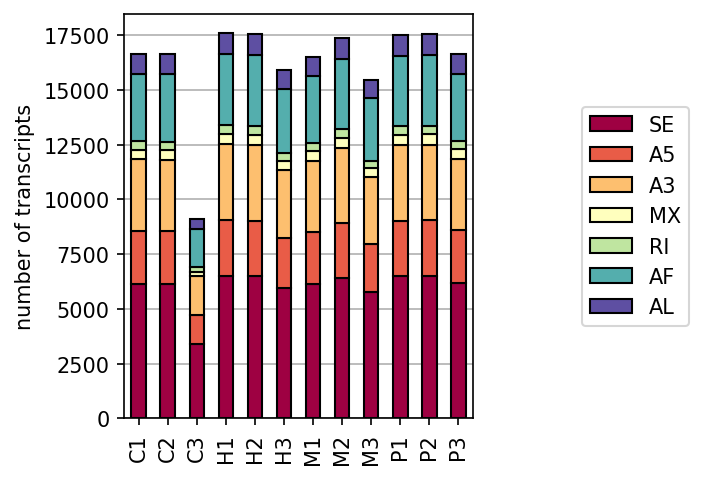

In [34]:
plot_df = pdf.copy()

# columns = [
#     'gene_name', 'transcript_name',
#     'transcript_type', 'uniprot',
#      'A3', 'A5', 'AF', 'AL', 'MX', 'RI', 'SE',
#     'Control', 'mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1',
# ]

columns_init = [
    'gene_name', 'transcript_name',
    'transcript_type', 'uniprot',
     'A3', 'A5', 'AF', 'AL', 'MX', 'RI', 'SE',
]

columns = columns_init + clusters

col_select = len(clusters)

plot_df = plot_df[columns]
plot_df = pd.melt(
    plot_df, id_vars=columns[:-col_select],
)

plot_df.head()

event_types = {
    'SE': 'skipping exon',
    'A5': "alternative 5' splice site",
    'A3': "alternative 3' splice site",
    'MX': 'mutually exclusive exon',
    'RI': 'retained intron',
    'AF': 'alternative first exon',
    'AL': 'alternative last exon',
}

results = []
for group_name, group in plot_df.groupby('variable'):
    group = group[group['transcript_type'] == 'protein_coding']
    group = group[group['uniprot'].notna()]

    row = {
        'group' : group_name,
    }

    for event_type, event_label in event_types.items():
        count = group[(group[event_type] == True) & (group['value'] > 0)]['transcript_name'].nunique()
        row[event_type] = count

    results.append(row)
    
results = pd.DataFrame(results)
results = results.set_index('group')
print(results.to_string())

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 3.5
results.plot(
    kind='bar',
    stacked=True,
    ec='k',
    zorder=10,
    cmap='Spectral'
)

plt.grid(axis='y', zorder=0)
plt.xlabel("")
plt.ylabel("number of transcripts")
sns.move_legend(
    plt.gca(),
    loc='center right',
    title='',
    bbox_to_anchor=(1.65, 0.5)
)

In [31]:
pdf['transcript_type'].value_counts()

transcript_type
protein_coding                    30439
lncRNA                            10880
retained_intron                    7705
protein_coding_CDS_not_defined     5086
nonsense_mediated_decay            3656
non_stop_decay                       32
TEC                                  29
protein_coding_LoF                    5
TR_V_gene                             5
IG_V_gene                             2
IG_V_pseudogene                       1
TR_J_gene                             1
TR_C_gene                             1
IG_C_pseudogene                       1
TR_V_pseudogene                       1
Name: count, dtype: int64

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
 [Text(0, 0, 'C1'),
  Text(1, 0, 'C2'),
  Text(2, 0, 'C3'),
  Text(3, 0, 'H1'),
  Text(4, 0, 'H2'),
  Text(5, 0, 'H3'),
  Text(6, 0, 'M1'),
  Text(7, 0, 'M2'),
  Text(8, 0, 'M3'),
  Text(9, 0, 'P1'),
  Text(10, 0, 'P2'),
  Text(11, 0, 'P3')])

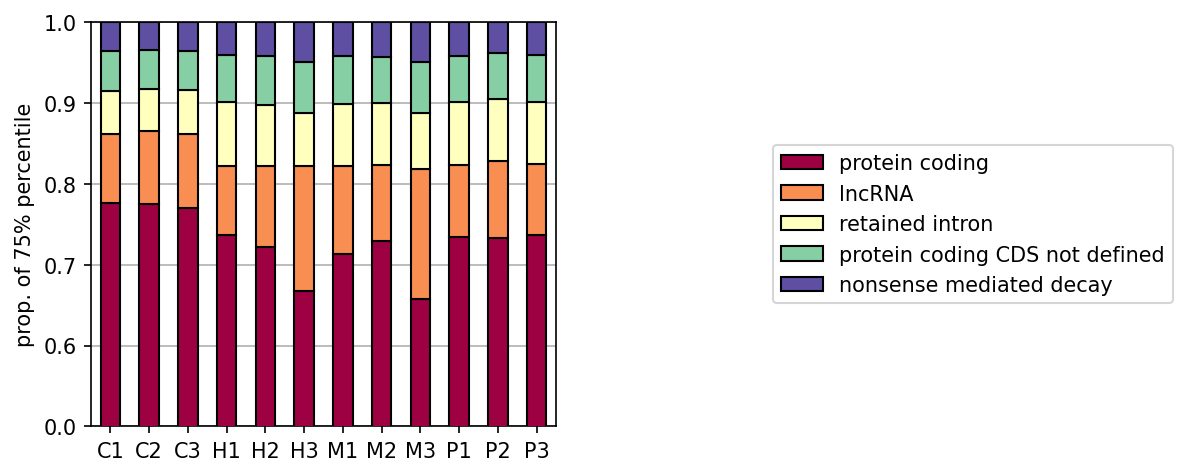

In [33]:
p = 0.75
# cols = ['Control', 'mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']

keep = [
    'retained_intron',
    'protein_coding_CDS_not_defined',
    'lncRNA',
    'protein_coding',
    'nonsense_mediated_decay',
    # 'protein_coding_LoF',
]

proportions = {}
for col in clusters:
    thresh = pdf[col].quantile(p)
    mask   = (pdf[col] > thresh) & pdf['transcript_type'].isin(keep)
    cnts   = pdf.loc[mask, 'transcript_type'].value_counts(normalize=True)
    cnts.index = cnts.index.str.replace("_", " ")
    proportions[col] = cnts

result = pd.DataFrame(proportions).fillna(0)

# pick the order you want – here, descending in “initial”
order = result['C1'].sort_values(ascending=False).index

# reindex so the stacks plot in that order
result = result.loc[order]
result = result.loc[(result != 0).any(axis=1)]

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 3.5
result.T.plot(
    kind='bar',
    stacked=True,
    ec='k',
    zorder=10,
    cmap='Spectral',
)

plt.grid(axis='y', zorder=0)
sns.move_legend(
    plt.gca(),
    loc='center right',
    title='',
    bbox_to_anchor=(2.35, 0.5)
)
plt.ylabel(f'prop. of {int(p*100)}% percentile')
plt.ylim([0.5, 1])#1.005])

ax = plt.gca()
yticks = ax.get_yticks()
yticklabels = [f"{round(t, 3)}" for t in yticks]
yticklabels[0] = 0.0    # set lowest label manually
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)
plt.xticks(rotation=0)

# Dominance

In [35]:
def get_top(df, col):
    # Remove groups with any NaN
    mask = df.groupby('gene_name', observed=True)[col].transform(lambda x: x.isna().any())
    df_valid = df[~mask]

    # Get index of max value per group
    top_idx = df_valid.groupby('gene_name', observed=True)[col].idxmax()
    counts = df_valid.groupby('gene_name', observed=True)[col].apply(lambda x: (x == x.max()).sum())

    # Build mapping and drop ties
    top_map = df_valid.loc[top_idx, ['gene_name', 'transcript_name']].set_index('gene_name')['transcript_name']
    top_map[counts > 1] = np.nan

    return df['gene_name'].map(top_map)


cols = [x + '_pct' for x in clusters]

for col in cols:
    pdf[f'{col}_top'] = get_top(pdf, col)

pdf.head()

,transcript_name,C1,C2,C3,H1,H2,H3,M1,M2,M3,...,C3_pct_top,H1_pct_top,H2_pct_top,H3_pct_top,M1_pct_top,M2_pct_top,M3_pct_top,P1_pct_top,P2_pct_top,P3_pct_top
0,A1BG-203,5.0,4.0,0.0,5.0,7.0,1.0,3.0,2.0,1.0,...,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204
1,A1BG-204,2500.0,3628.0,38.0,657.0,812.0,180.0,360.0,534.0,100.0,...,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204
2,A1BG-AS1-202,16.0,18.0,0.0,12.0,2.0,3.0,2.0,1.0,1.0,...,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-209,A1BG-AS1-209
3,A1BG-AS1-203,7.0,12.0,0.0,5.0,6.0,1.0,1.0,0.0,1.0,...,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-209,A1BG-AS1-209
4,A1BG-AS1-204,52.0,41.0,3.0,23.0,33.0,11.0,12.0,19.0,10.0,...,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-209,A1BG-AS1-209


In [36]:
def find_dominant_isoforms(
    plot_df: pd.DataFrame,
    clusters: list[str],
    require_protein_coding: bool = True,
    require_lcrna: bool = False,
    require_uniprot: bool = True,
    require_tf: bool = False
) -> pd.DataFrame:
    """
    Find genes where a transcript is dominant in exactly one group.

    Parameters
    ----------
    plot_df : pd.DataFrame
        Input dataframe with columns:
        - transcript_name
        - transcript_type
        - uniprot
        - is_tf (optional)
        - *_pct_top (for each cluster)
    clusters : list[str]
        List of cluster names (used to construct *_pct_top column names).
    require_protein_coding : bool, default=True
        If True, keep only protein_coding transcripts.
    require_uniprot : bool, default=True
        If True, keep only transcripts with UniProt mapping.
    require_tf : bool, default=False
        If True, keep only transcription factors (plot_df['is_tf'] == True).

    Returns
    -------
    results : pd.DataFrame
        Columns:
        - gene_name
        - group (cluster where it's dominant)
    """
    top_cols = [x + '_pct_top' for x in clusters]
    results = []

    for column in top_cols:
        label = column.replace("_pct_top", "")
        other_columns = [c for c in top_cols if c != column]

        mask = (
            (plot_df['transcript_name'] == plot_df[column]) &
            (plot_df[other_columns].ne(plot_df[column], axis=0).all(axis=1))
        )

        if require_protein_coding:
            mask &= plot_df['transcript_type'] == 'protein_coding'
        if require_lcrna:
            mask &= plot_df['transcript_type'] == 'lncRNA'
        if require_uniprot:
            mask &= plot_df['uniprot'].notna()
        if require_tf and 'is_tf' in plot_df.columns:
            mask &= plot_df['is_tf']

        dominant_iso = plot_df[mask].copy()
        tmp = pd.DataFrame(dominant_iso['gene_name'].unique(), columns=['gene_name'])
        tmp['group'] = label
        results.append(tmp)

    if results:
        results = pd.concat(results, ignore_index=True)
    else:
        results = pd.DataFrame(columns=['gene_name', 'group'])

    return results

In [37]:
plot_df = pdf.copy()
# print(plot_df.columns)
# print()

# Remove mitochondrial and ribosomal genes
plot_df = plot_df[~plot_df['gene_name'].str.startswith("MT")]
plot_df = plot_df[~plot_df['gene_name'].str.startswith("RP")]

res_tfs = find_dominant_isoforms(plot_df, clusters, 
                                 require_protein_coding=True, 
                                 require_uniprot=True,
                                 require_tf=True)

print(f"TFs:\n{res_tfs.groupby('group')['gene_name'].nunique()}")

res_pc = find_dominant_isoforms(plot_df, clusters, 
                                 require_protein_coding=True, 
                                 require_uniprot=True,
                                 require_tf=False)

print(f"\nProtein-coding:\n{res_pc.groupby('group')['gene_name'].nunique()}")

res_lcrna = find_dominant_isoforms(plot_df, clusters, 
                                 require_protein_coding=False, 
                                 require_lcrna=True,
                                 require_uniprot=False,
                                 require_tf=False)

print(f"\nLncRNAs:\n{res_lcrna.groupby('group')['gene_name'].nunique()}")

res_all = find_dominant_isoforms(plot_df, clusters, 
                                 require_protein_coding=False, 
                                 require_uniprot=True,
                                 require_tf=False)

print(f"\nAll transcripts:\n{res_all.groupby('group')['gene_name'].nunique()}")

TFs:
group
C1    15
C2     9
C3    17
H1     2
H2     3
H3    12
M1     4
M2     2
M3    14
P1     4
P2     5
P3     5
Name: gene_name, dtype: int64

Protein-coding:
group
C1    110
C2     93
C3    181
H1     28
H2     18
H3    126
M1     66
M2     25
M3    124
P1     34
P2     35
P3     56
Name: gene_name, dtype: int64

LncRNAs:
group
C1     67
C2     65
C3    101
H1     26
H2     18
H3     52
M1     51
M2     15
M3     70
P1     19
P2     18
P3     37
Name: gene_name, dtype: int64

All transcripts:
group
C1    119
C2    109
C3    219
H1     33
H2     24
H3    153
M1     82
M2     29
M3    171
P1     38
P2     37
P3     64
Name: gene_name, dtype: int64


In [38]:
tmp1 = res_pc[res_pc['group'] == 'M3']
tmp1 = tmp1[~tmp1['gene_name'].str.startswith('Z')]
print(", ".join(tmp1['gene_name'].unique()))

ABHD11, ALAS1, AMACR, ANO3, APAF1, ARHGAP12, ARID2, B4GALT7, BACH2, BBX, BTBD9, BTD, BTG4, C17orf80, CASP9, CCNC, CDC42, CIITA, CIZ1, CLEC16A, CLTCL1, CPED1, CPSF4, CREB3L4, CTNNA1, DAB2, DDX54, DNAJC19, DUS2, ELP1, FANCL, FBLN5, FHAD1, FOXRED1, G6PC3, GATB, GLB1, GLT8D1, GOLGA7, HAPSTR1, HECTD2, HECTD4, HP1BP3, HS1BP3, HSDL1, HYOU1, IFI16, IMMT, INTS13, KANTR, KIAA0930, KMT2C, LAS1L, LCLAT1, LRRC8A, LZTS2, MDGA1, MDM1, MFF, MMP14, MPHOSPH9, NAA60, NAA80, NAP1L1, NAT9, NCAPH, NDEL1, OAZ3, PABPC4, PARN, PDGFRB, PDZRN3, PGM3, PIK3R1, PIK3R4, PLAAT3, PLAC8, PLAT, POR, PREPL, PTPN3, QSOX1, RAB3A, RAPGEFL1, RFX8, RNF13, RUVBL1, SBF2, SCLY, SHF, SIRT2, SLC2A8, SLC10A7, SLC24A1, SLC35C2, SLC39A11, SPAG1, SPICE1, SRSF1, SUSD3, TBC1D31, TCFL5, THADA, THYN1, TMEM25, TMEM80, TP53, TRABD, TRDMT1, TSNARE1, TWF1, VSTM1, WLS, XNDC1N


In [54]:
tmp1 = res_tfs[res_tfs['group'] == 'M3']
tmp1 = tmp1[~tmp1['gene_name'].str.startswith('Z')]
print(", ".join(tmp1['gene_name'].unique()))

BRCA1, CREB1, HES4, HP1BP3, MAF, MSRB3, NAP1L1, RARB, RFX8, TCF3


23
FOXO3


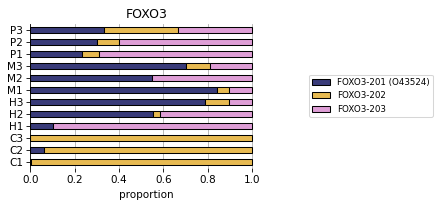

JUN


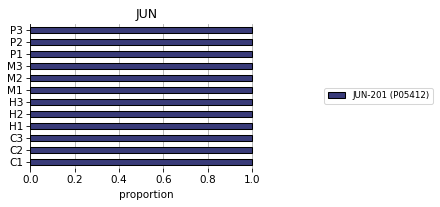

JUNB


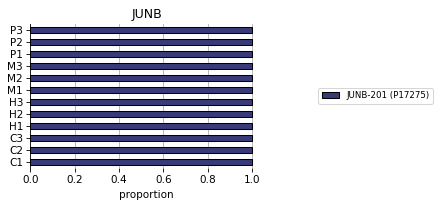

RUNX1


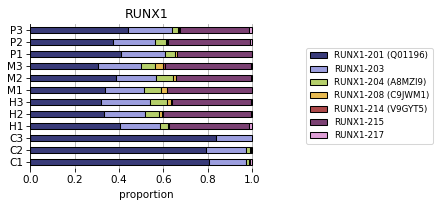

CDK6


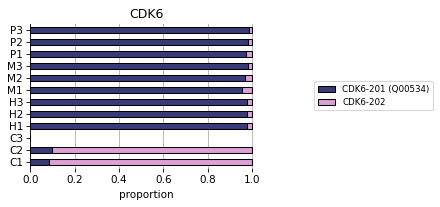

NUMB


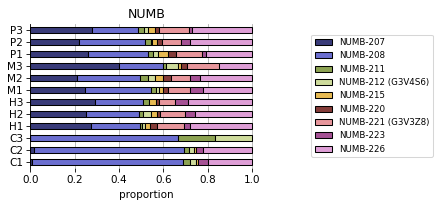

ATF3


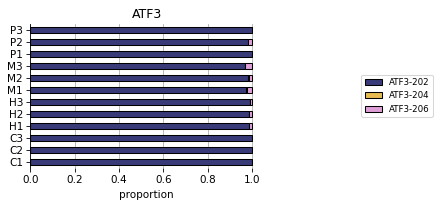

ATF4


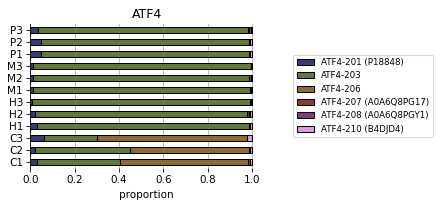

TWIST1


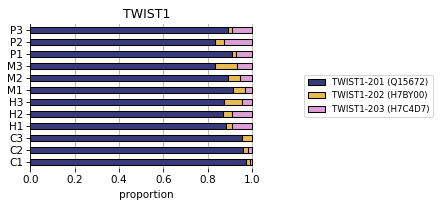

TWIST2


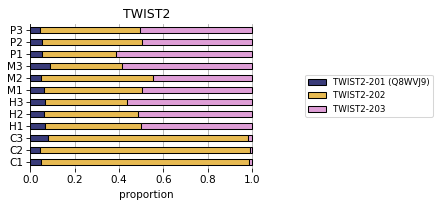

TP53


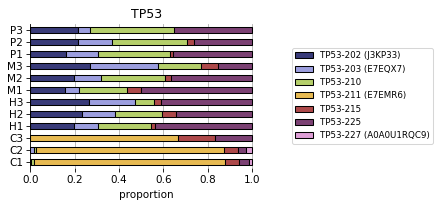

AKT1


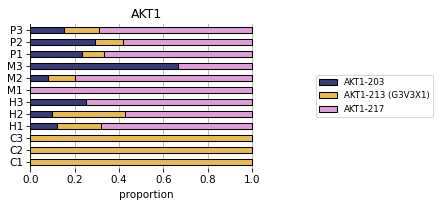

YWHAZ


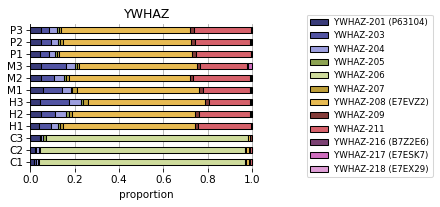

YWHAE


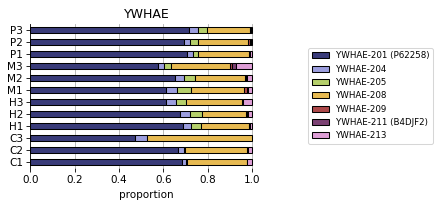

SRF


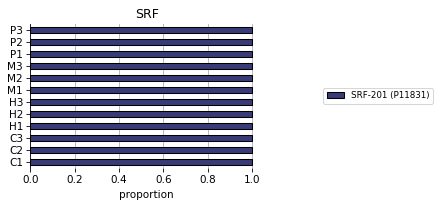

PBX1


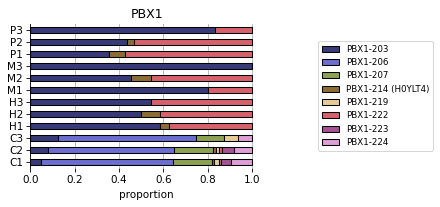

ID1


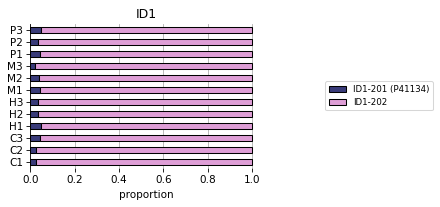

ID2


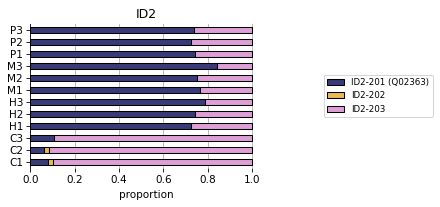

EP300


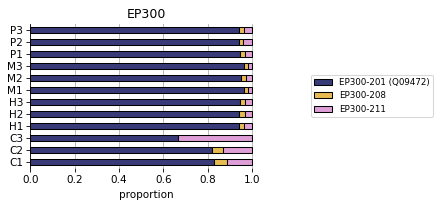

EID1


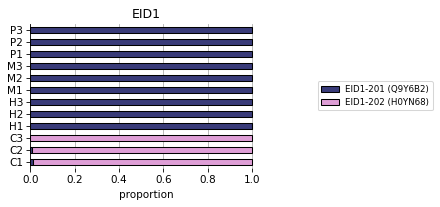

SMARCA4


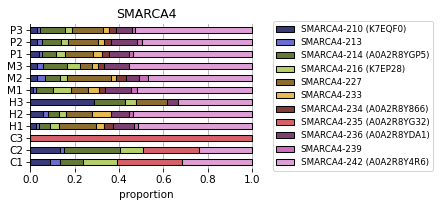

KAT2B


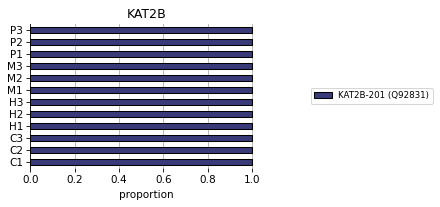

KAT5


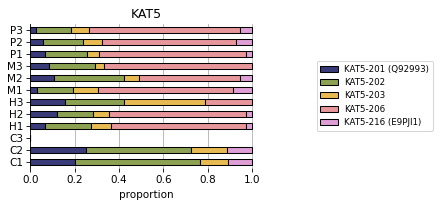

In [39]:
plot_df = pdf.copy()

genes_of_interest = [
    ### H3
    # 'SMARCA2', 'SMURF1', 'CDK11A', 'CCDC82', 'CCDC97', 'CCDC171', 'COL27A1', 'CPEB3', 'CSNK1E',
    # 'HDAC6', 'HNRNPF',
    ### M3
    # 'BMP4', 'CCNC', 'TSPAN4',
    ### P3
    # 'DYRK1A', 'ELN', 'SETD4', 'HOOK2', 'CDH13', 'LAMA3', 'ERN1',
    ### M2
    # 'CDC34', 'CNOT1', 'EIF2AK2', 'HNRNPH1', 'MAP2K6',  
    ### M1
    # 'BMP1', 'CCNL1', 'CHD3', 'COL10A1', 'CREBBP', 'DPF3', 'ETV2', 'PDGFRB', 
    ### P1
    # 'MAPK6', 'MAPK10', 'PTK2', 'BEST3',
    
    'FOXO3', 'JUN', 'JUNB', 'RUNX1', 'CDK6', 'NUMB', 'ATF3', 'ATF4', 'TWIST1', 'TWIST2',
    'TP53', 'AKT1', 'YWHAZ', 'YWHAE', 'SRF', 'PBX1', 'ID1', 'ID2', 'EP300', 'EID1', 
    'SMARCA4', 'KAT2B', 'KAT5',
    
]

genes_of_interest = [g for g in genes_of_interest if g in plot_df['gene_name'].unique()]
print(len(genes_of_interest))

for gene in genes_of_interest:
    print(gene)

    gene_df = plot_df[plot_df['gene_name'] == gene].reset_index()

    # Option 1: using np.where
    gene_df['annotation'] = (
        gene_df['transcript_name']
        + np.where(
            gene_df['uniprot'].notna(),
            ' (' + gene_df['uniprot'] + ')',
            ''
        )
    )
    
    tmp = gene_df.set_index('annotation').copy()
    tmp = tmp[cols]
    tmp.columns = [x.replace("_pct", "") for x in tmp.columns]

    plt.rcParams['figure.dpi'] = 75
    plt.rcParams['figure.figsize'] = 4, 2.5

    # 1) Plot figure without legend
    fig1, ax1 = plt.subplots()
    tmp.T.plot(
        kind='barh',
        stacked=True,
        ec='k',
        zorder=10,
        width=0.5,
        cmap='tab20b',
        ax=ax1
    )
    ax1.grid(axis='x', zorder=0)
    ax1.set_xlabel("proportion")
    sns.move_legend(
        ax1,
        loc='center right',
        title="",
        bbox_to_anchor=(1.75, 0.5),
        fontsize='small',
    )
    ax1.set_title(gene)
    sns.despine(bottom=True)
    plt.show()

5
VGLL4


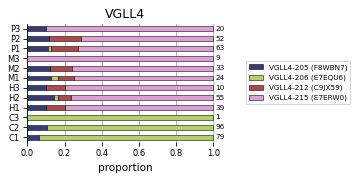

TP53


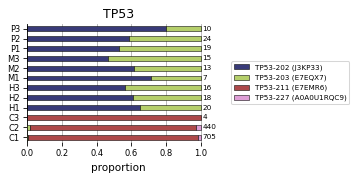

RUNX1


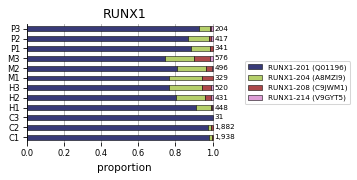

MAP4


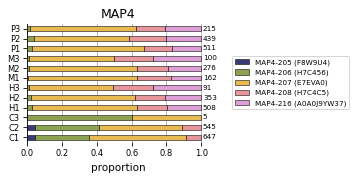

EID1


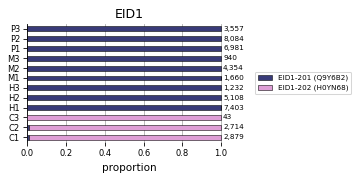

In [40]:
plot_df = pdf.copy()

clusters = ['C1', 'C2', 'C3', 'H1', 'H2', 'H3', 'M1', 'M2', 'M3', 'P1', 'P2', 'P3']
cols = [x + '_pct' for x in clusters]

# genes_of_interest = ['MAZ', 'HES4', 'BRCA1', 'CREB1', 'SMARCA4', 'SMURF1', 'HDAC6']
genes_of_interest = ['VGLL4', 'TP53', 'RUNX1', 'MAP4', 'EID1']

genes_of_interest = [g for g in genes_of_interest if g in plot_df['gene_name'].unique()]
print(len(genes_of_interest))


for gene in genes_of_interest:
    print(gene)

    gene_df = plot_df[plot_df['gene_name'] == gene].reset_index()
    gene_df = gene_df[gene_df['uniprot'].notna()]

    # Option 1: using np.where
    gene_df['annotation'] = (
        gene_df['transcript_name']
        + np.where(
            gene_df['uniprot'].notna(),
            ' (' + gene_df['uniprot'] + ')',
            ''
        )
    )
    
    tmp = gene_df.set_index('annotation').copy()
    tmp = tmp[cols]
    tmp.columns = [x.replace("_pct", "") for x in tmp.columns]
    
    col_sums = tmp.sum(axis=0)
    col_sums[col_sums == 0] = 1
    
    tmp = tmp.div(col_sums, axis=1)
    
    
    cluster_totals = gene_df[clusters].sum(axis=0)

    plt.rcParams['figure.dpi'] = 75
    plt.rcParams['figure.figsize'] = 5, 2.5

    # 1) Plot figure without legend
    fig1, ax1 = plt.subplots()
    tmp.T.plot(
        kind='barh',
        stacked=True,
        ec='k',
        zorder=10,
        width=0.5,
        linewidth=0.5,
        cmap='tab20b',
        ax=ax1
    )
    ax1.grid(axis='x', zorder=0)
    ax1.set_xlabel("proportion")
    ax1.tick_params(axis='both', labelsize=8)
    sns.move_legend(
        ax1,
        loc='center left',
        title="",
        bbox_to_anchor=(1.1, 0.5),
        fontsize='x-small',
    )
    ax1.set_title(gene)
    sns.despine(bottom=True)
    
    for i, cluster in enumerate(tmp.columns):
        bar_total_proportion = tmp[cluster].sum()
        count = cluster_totals[cluster]
        yloc = i
        ax1.text(bar_total_proportion + 0.01, yloc, f'{int(count):,}',
                 va='center', ha='left', fontsize=7, color='black')
    
    plt.tight_layout()
    plt.show()

Index(['transcript_name', 'C1', 'C2', 'C3', 'H1', 'H2', 'H3', 'M1', 'M2', 'M3',
       'P1', 'P2', 'P3', 'total_transcript', 'gene_name', 'gene_type',
       'transcript_type', 'is_tf', 'uniprot', 'A3', 'A5', 'AF', 'AL', 'MX',
       'RI', 'SE', 'num_events', 'n_isoforms', 'n_protiens', 'C1_sum',
       'C2_sum', 'C3_sum', 'H1_sum', 'H2_sum', 'H3_sum', 'M1_sum', 'M2_sum',
       'M3_sum', 'P1_sum', 'P2_sum', 'P3_sum', 'total_gene', 'C1_pct',
       'C2_pct', 'C3_pct', 'H1_pct', 'H2_pct', 'H3_pct', 'M1_pct', 'M2_pct',
       'M3_pct', 'P1_pct', 'P2_pct', 'P3_pct', 'C1_pct_top', 'C2_pct_top',
       'C3_pct_top', 'H1_pct_top', 'H2_pct_top', 'H3_pct_top', 'M1_pct_top',
       'M2_pct_top', 'M3_pct_top', 'P1_pct_top', 'P2_pct_top', 'P3_pct_top'],
      dtype='object')

MEF2C


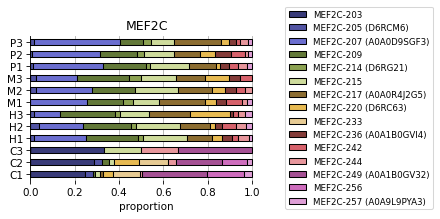

SGSM2


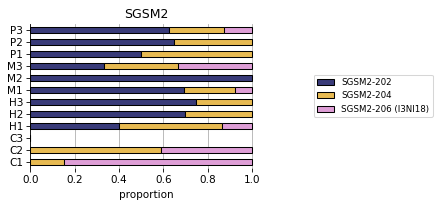

STAT2


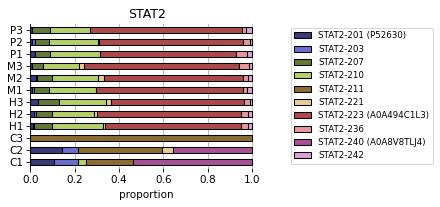

ZBTB4


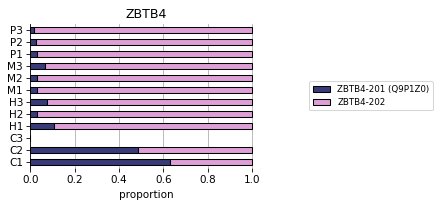

ZBTB48


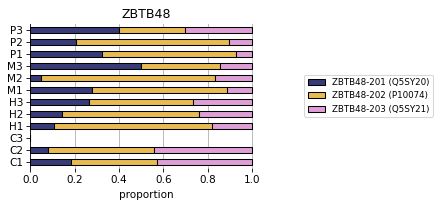

ZFX


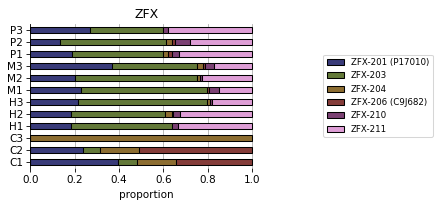

ZNF107


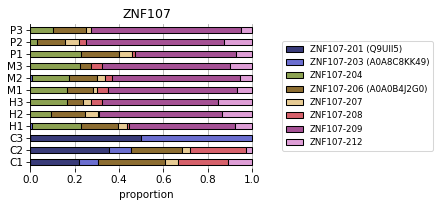

ZNF155


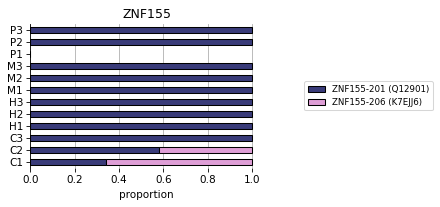

ZNF195


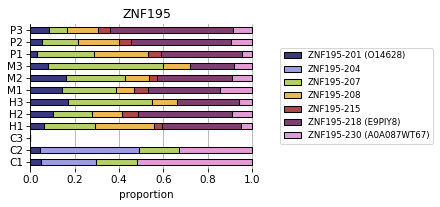

ZNF264


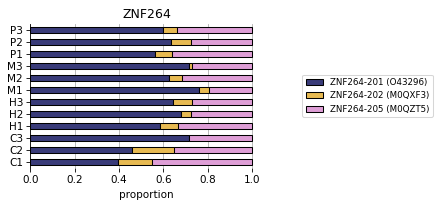

ZNF302


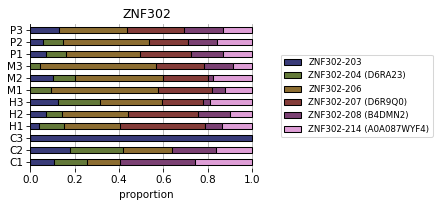

ZNF334


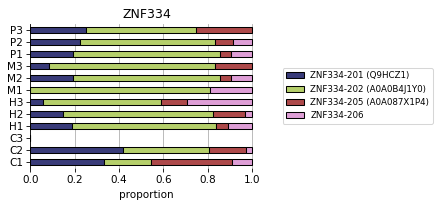

ZNF384


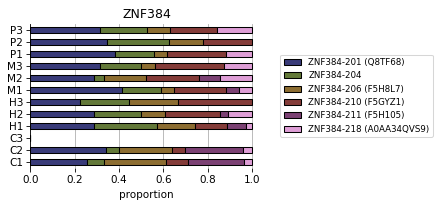

ZNF440


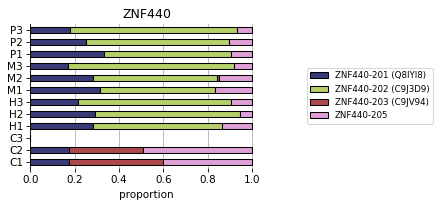

ZNF772


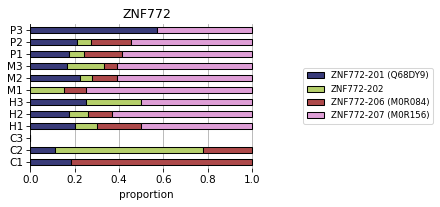

FIZ1


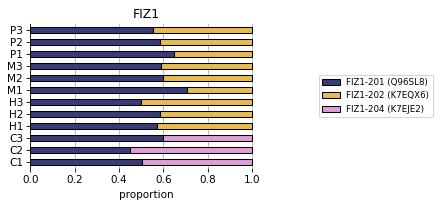

FOSB


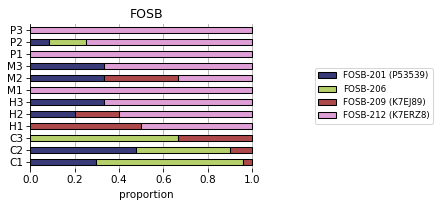

KDM5B


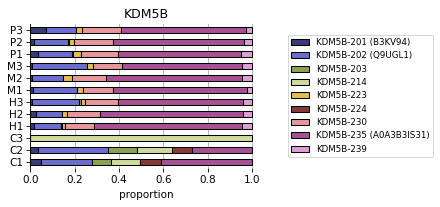

ZNF227


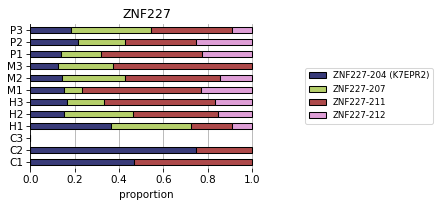

ZNF724


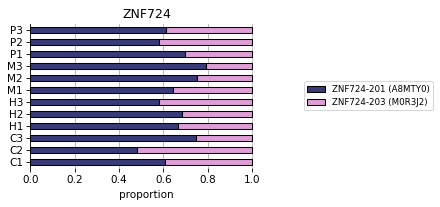

CIC


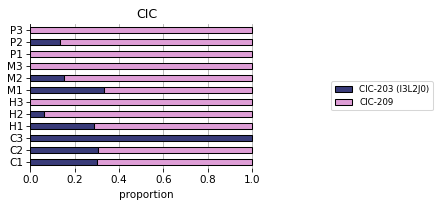

ETV5


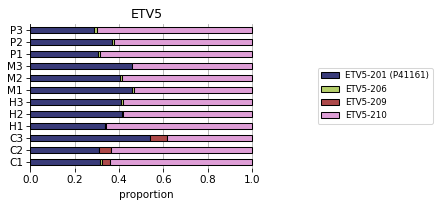

FLYWCH1


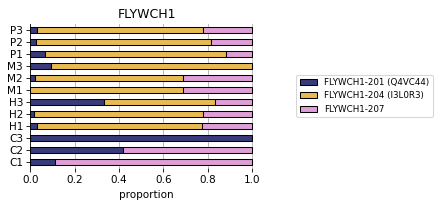

HMG20A


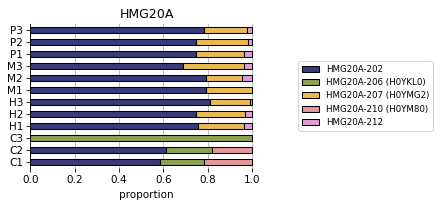

HOXC11


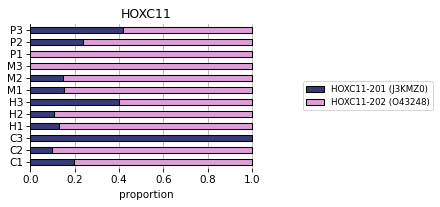

LCORL


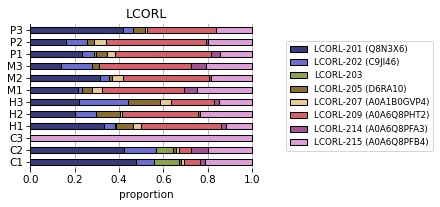

NFKB1


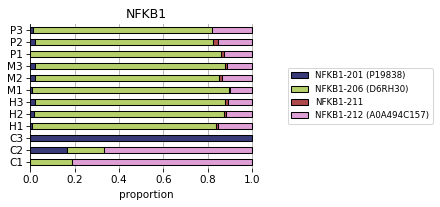

RORA


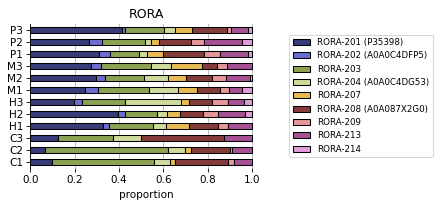

ZIC1


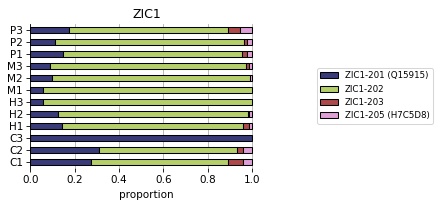

ZNF117


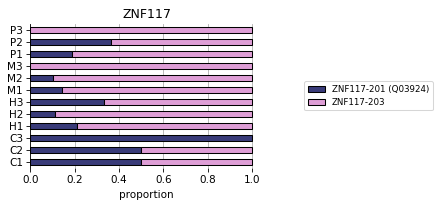

ZNF300


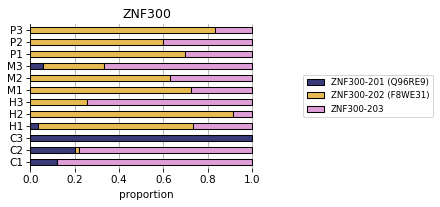

ZNF469


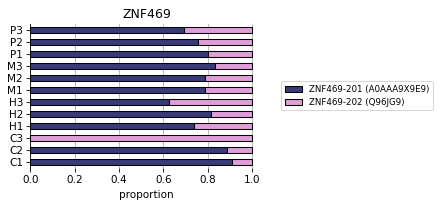

ZNF517


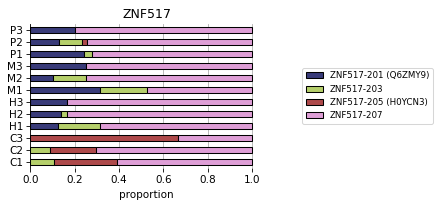

ZNF589


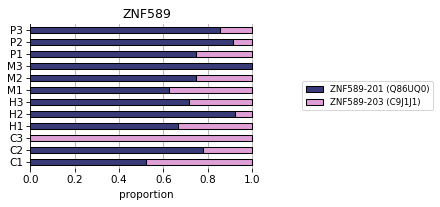

ZNF669


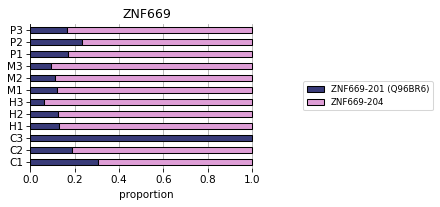

ZNF789


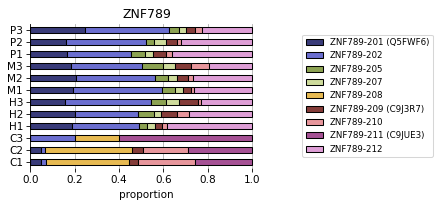

ZSCAN5A


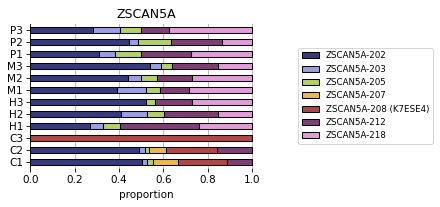

TBPL1


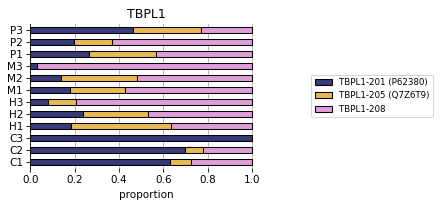

ZNF250


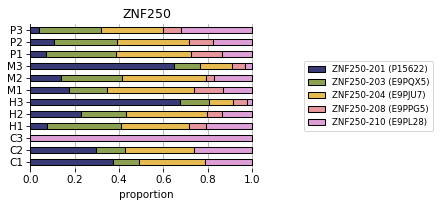

KLF4


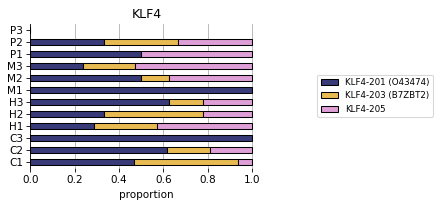

NR4A1


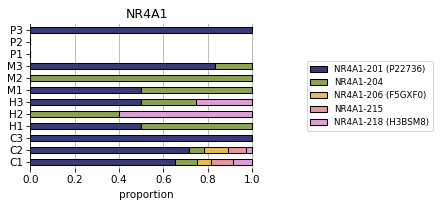

ZNF606


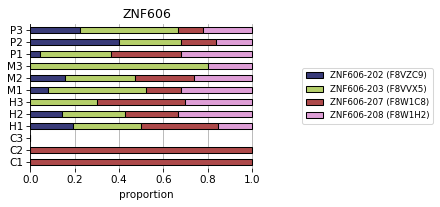

ARNT2


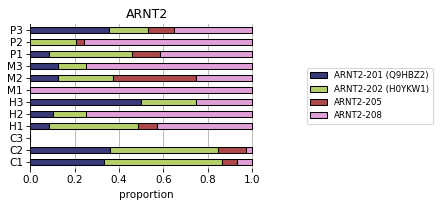

BACH1


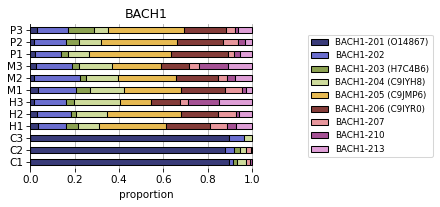

DLX1


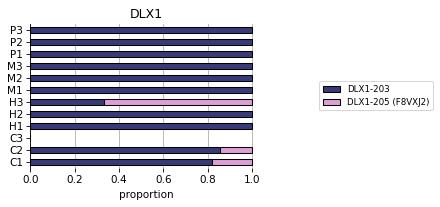

HMBOX1


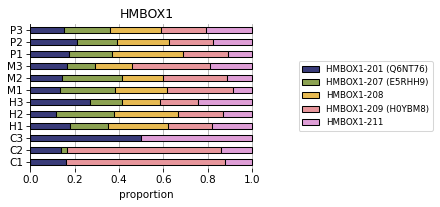

MAZ


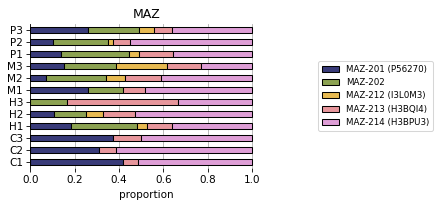

MSANTD4


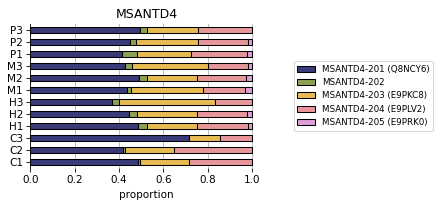

THRA


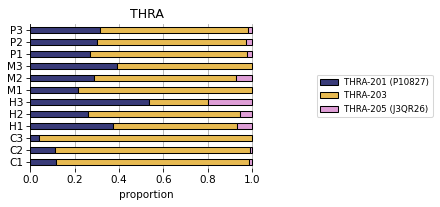

ZFP90


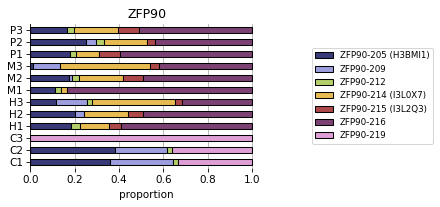

ZNF75A


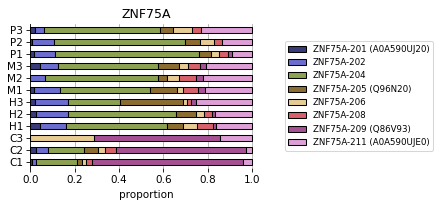

ZNF454


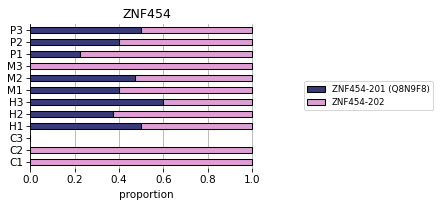

GLMP


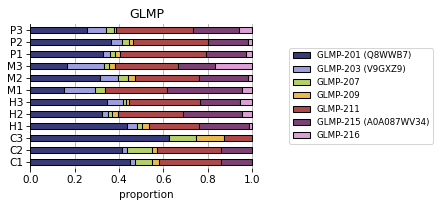

NFE2L3


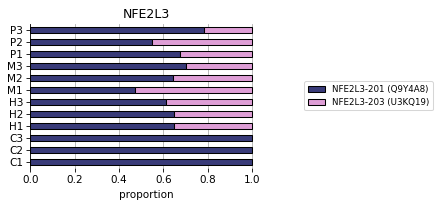

THAP9


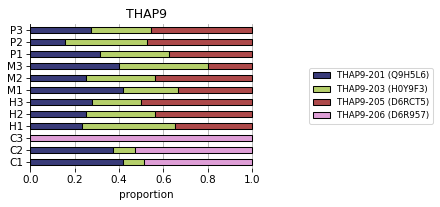

ZNF391


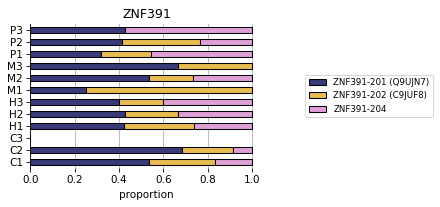

TBX18


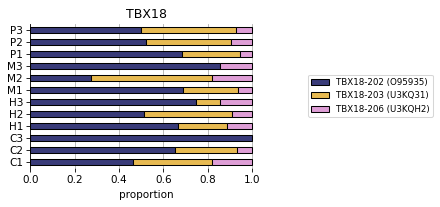

ZNF714


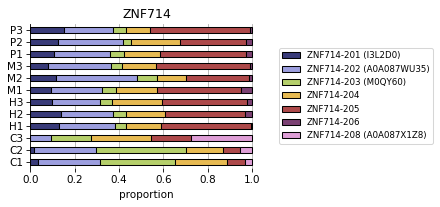

ARID2


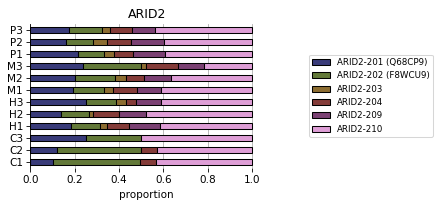

BACH2


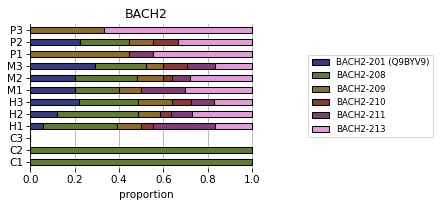

BBX


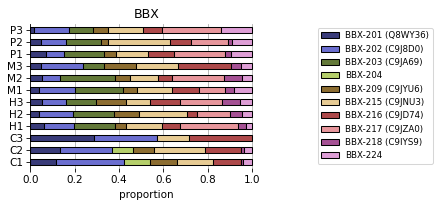

CREB3L4


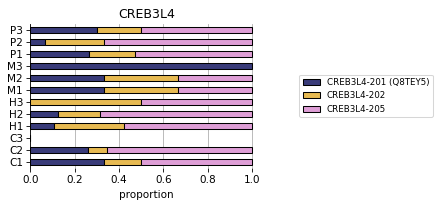

RFX8


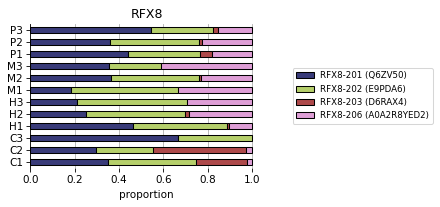

TCFL5


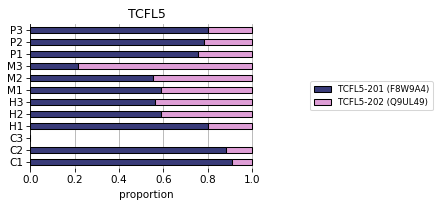

THYN1


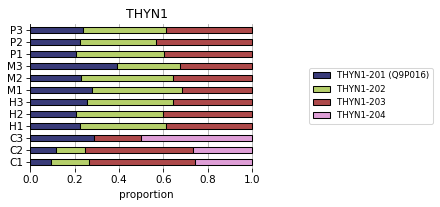

TP53


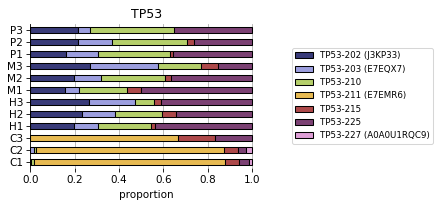

ZFP30


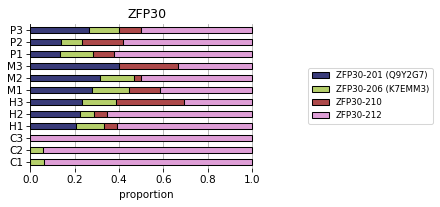

ZFP69B


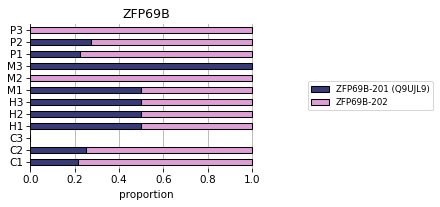

ZNF37A


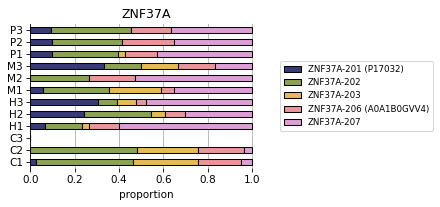

ZNF66


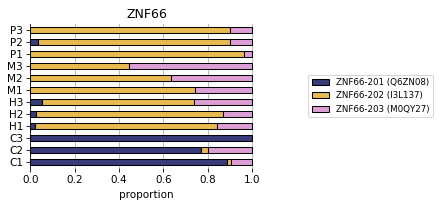

ZNF385D


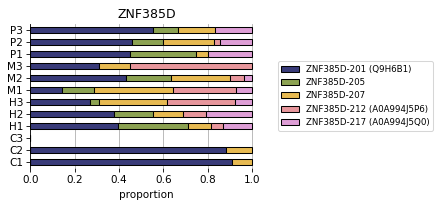

ZNF519


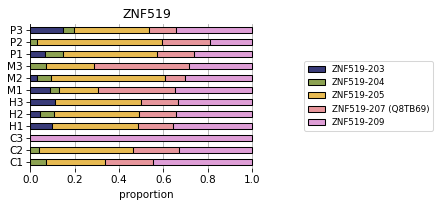

ZNF33A


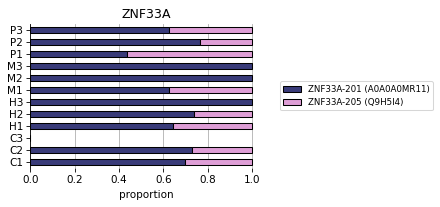

ZNF135


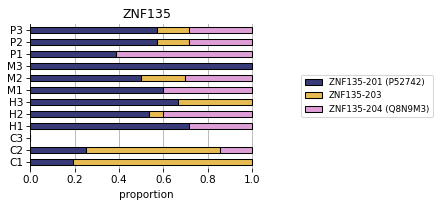

ZNF442


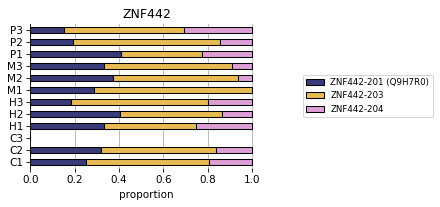

ZNF514


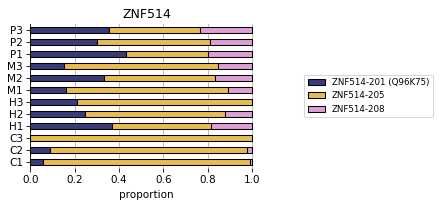

NFATC4


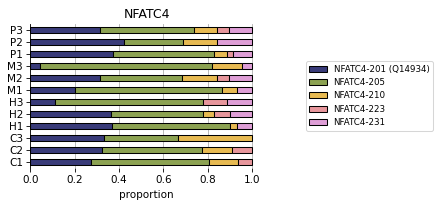

ZNF474


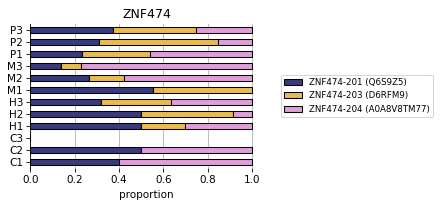

ZNF701


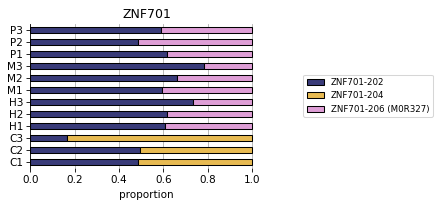

ZSCAN32


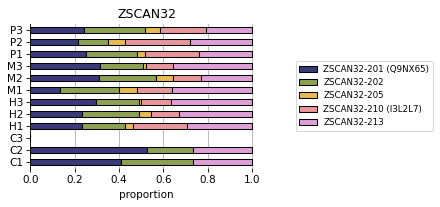

ZNF578


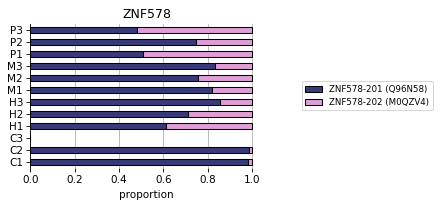

ZNF625


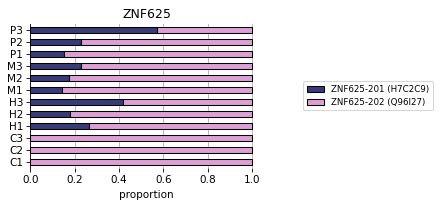

ZNF696


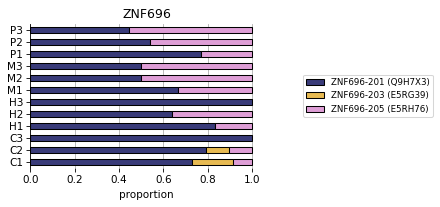

ZNF706


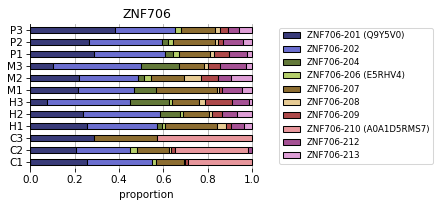

In [42]:
plot_df = pdf.copy()
print(plot_df.columns)
print()

annotation_cols = ['transcript_name', 'transcript_type', 'uniprot', 'A3', 'A5', 'AF', 'AL', 'MX', 'RI', 'SE']


# results = results[results['group'] != 'Control']


counter = 0

for gene in res_tfs['gene_name'].unique():#values:
    print(gene)

    gene_df = plot_df[plot_df['gene_name'] == gene].reset_index()

    # Option 1: using np.where
    gene_df['annotation'] = (
        gene_df['transcript_name']
        + np.where(
            gene_df['uniprot'].notna(),
            ' (' + gene_df['uniprot'] + ')',
            ''
        )
    )
    
    tmp = gene_df.set_index('annotation').copy()
    tmp = tmp[cols]
    tmp.columns = [x.replace("_pct", "") for x in tmp.columns]

    plt.rcParams['figure.dpi'] = 75
    plt.rcParams['figure.figsize'] = 4, 2.5 #3.75, 1.5

    # 1) Plot figure without legend
    fig1, ax1 = plt.subplots()
    tmp.T.plot(
        kind='barh',
        stacked=True,
        ec='k',
        zorder=10,
        width=0.5,
        cmap='tab20b',
        ax=ax1
    )
    ax1.grid(axis='x', zorder=0)
    ax1.set_xlabel("proportion")
    sns.move_legend(
        ax1,
        loc='center right',
        title="",
        bbox_to_anchor=(1.75, 0.5),
        fontsize='small',
    )
    ax1.set_title(gene)
    sns.despine(bottom=True)
    plt.show()
    
    # break
    # # break
    # counter += 1
    # if counter >= 10:
    #     break
    


In [ ]:
# plot_df = pdf.copy()

# genes_of_interest = [
#     'MYOD1', 'PRRX1', 'CEBPB', 'TWIST1', 'TWIST2', 'ZEB1', 'VGLL4', 'SIX1', 'PBX1', 'CHD2', 'ID1', 'ID2', 'ID3', 'SP1', 'SNAI1', 'SNAI2',
#     'TGFBR1', 'EP300', 'CREBBP', 'KAT2B', 'HDAC1', 'HDAC9', 'EZH2', 'CCND1', 'CHEK2', 'CDK1', 'CDK4', 'UBE2C', 'MYC', 'FOXM1', 'MYBL2', 'LEO1', 
#     'RBL1', 'RBL1', 'RB1', 'ITGB1', 'RUNX1', 'NFKB1', 'JUN', 'JUNB', 'FOS', 'FOSB', 'COL1A1', 'COL1A2', 'S100A6', 'PPP2CA', 'PPP1CA', 'MEF2A',
#     'PCLAF', 'NUMB', 'PARD3', 'CDC42', 'NOTCH2', 'SAV1', 'YAP1', 'MOB1A', 'LATS1', 'LATS2', 'WWTR1', 'TEAD1', 'STAT1', 'CTCF', 'KLF4', 
# ]

# genes_of_interest = [g for g in genes_of_interest if g in plot_df['gene_name'].unique()]
# print(len(genes_of_interest))

# for gene in genes_of_interest:
#     print(gene)

#     gene_df = plot_df[plot_df['gene_name'] == gene].reset_index()

#     # Option 1: using np.where
#     gene_df['annotation'] = (
#         gene_df['transcript_name']
#         + np.where(
#             gene_df['uniprot'].notna(),
#             ' (' + gene_df['uniprot'] + ')',
#             ''
#         )
#     )
    
#     tmp = gene_df.set_index('annotation').copy()
#     tmp = tmp[['Control_pct', 'mmMYOD1_pct', 'siPRRX1_pct', 'siPRRX1/mmMYOD1_pct']]
#     tmp.columns = [x.replace("_pct", "") for x in tmp.columns]

#     plt.rcParams['figure.dpi'] = 75
#     plt.rcParams['figure.figsize'] = 3.75, 1.5

#     # 1) Plot figure without legend
#     fig1, ax1 = plt.subplots()
#     tmp.T.plot(
#         kind='barh',
#         stacked=True,
#         ec='k',
#         zorder=10,
#         width=0.5,
#         cmap='tab20b',
#         ax=ax1
#     )
#     ax1.grid(axis='x', zorder=0)
#     ax1.set_xlabel("proportion")
#     sns.move_legend(
#         ax1,
#         loc='center right',
#         title="",
#         bbox_to_anchor=(1.75, 0.5),
#         fontsize='small',
#     )
#     ax1.set_title(gene)
#     sns.despine(bottom=True)
#     plt.show()

In [43]:
def find_isoform_switches_onlycoding_uniprot(
    plot_df: pd.DataFrame,
    ref_clusters: list[str],
    test_clusters: list[str]
) -> pd.DataFrame:
    """
    Only considers protein-coding isoforms with UniProt IDs when determining dominant isoforms.
    """
    switches = []
    used_clusters = list(set(ref_clusters + test_clusters))
    for gene, group in plot_df.groupby('gene_name', observed=True):
        # Filter for protein-coding and UniProt only
        coding_uniprot = group[
            (group['transcript_type'] == 'protein_coding') & 
            (group['uniprot'].notna())
        ]
        if coding_uniprot.empty:
            continue
        
        # For each cluster, find the dominant isoform among the allowed ones
        dominant_by_cluster = {}
        for clu in used_clusters:
            # If the count column doesn't exist, skip
            if clu not in coding_uniprot.columns:
                continue
            clu_counts = coding_uniprot[[clu, 'transcript_name']]
            max_count = clu_counts[clu].max()
            # Ignore clusters where all counts are zero/missing
            if pd.isna(max_count) or max_count == 0:
                continue
            dominant_isoforms = set(clu_counts[clu_counts[clu]==max_count]['transcript_name'])
            dominant_by_cluster[clu] = dominant_isoforms
        
        # If missing any cluster, skip gene
        if not all(clu in dominant_by_cluster for clu in used_clusters):
            continue

        # Reference dominant isoforms (all unique in reference clusters)
        ref_doms = set()
        for clu in ref_clusters:
            ref_doms.update(dominant_by_cluster[clu])
        
        # For each test cluster, is its dominant isoform not in ref?
        for clu in test_clusters:
            for test_dom in dominant_by_cluster[clu]:
                if test_dom not in ref_doms:
                    # Counts restricted to coding_uniprot only!
                    ref_total = coding_uniprot[ref_clusters].sum().sum()
                    test_total = coding_uniprot[clu].sum()
                    switches.append({
                        'gene_name': gene,
                        'test_cluster': clu,
                        'ref_dominant_transcript': ','.join(sorted(ref_doms)),
                        'test_dominant_transcript': test_dom,
                        'ref_total_count': int(ref_total),
                        'test_total_count': int(test_total)
                    })
    return pd.DataFrame(switches)

In [44]:
plot_df = pdf.copy()

plot_df = plot_df[~plot_df['gene_name'].str.startswith("MT")]
plot_df = plot_df[~plot_df['gene_name'].str.startswith("RP")]

switches_df = find_isoform_switches_onlycoding_uniprot(
    plot_df,
    ref_clusters=['C1', 'C2'],
    test_clusters=['M3', 'H3']
)
switches_df.head()

,gene_name,test_cluster,ref_dominant_transcript,test_dominant_transcript,ref_total_count,test_total_count
0,AASDH,M3,AASDH-210,AASDH-201,100,2
1,AASDH,H3,AASDH-210,AASDH-201,100,3
2,ABCA1,M3,ABCA1-205,ABCA1-202,86,40
3,ABCA1,H3,ABCA1-205,ABCA1-202,86,59
4,ABCA5,M3,ABCA5-213,ABCA5-201,181,48


In [45]:
switches_df['test_total_count'].describe()

count    2788.000000
mean       45.013989
std       122.070507
min         1.000000
25%         6.000000
50%        15.000000
75%        38.000000
max      3184.000000
Name: test_total_count, dtype: float64

In [46]:
sdf = switches_df[switches_df['test_total_count'] >= 20].copy()
sdf = sdf[sdf['ref_dominant_transcript'] != 'NA']
sdf['count_diff'] = abs(sdf['ref_total_count'] - sdf['test_total_count'])
sdf['total_counts'] = sdf['ref_total_count'] + sdf['test_total_count']

sdf = sdf.sort_values(by=['test_total_count', 'count_diff'], ascending=[False, True])

sdf.head(10)

,gene_name,test_cluster,ref_dominant_transcript,test_dominant_transcript,ref_total_count,test_total_count,count_diff,total_counts
376,CD63,H3,CD63-213,CD63-201,71,3184,3113,3255
375,CD63,M3,CD63-213,CD63-201,71,2149,2078,2220
294,C12orf57,H3,C12orf57-201,C12orf57-202,55245,1649,53596,56894
1417,NAV3,H3,NAV3-207,NAV3-209,82,1483,1401,1565
715,EID1,H3,EID1-202,EID1-201,5593,1232,4361,6825
1416,NAV3,M3,NAV3-207,NAV3-209,82,1133,1051,1215
1895,RGMB,H3,RGMB-201,RGMB-207,8344,1043,7301,9387
2488,UBE2B,H3,UBE2B-201,UBE2B-206,12929,971,11958,13900
714,EID1,M3,EID1-202,EID1-201,5593,940,4653,6533
2173,SSH2,H3,SSH2-210,SSH2-212,527,934,407,1461


In [47]:
sdf['gene_name'].unique()[:100]

array(['CD63', 'C12orf57', 'NAV3', 'EID1', 'RGMB', 'UBE2B', 'SSH2',
       'PPP1R15A', 'TFPI', 'PSME1', 'PPP1R14B', 'NUP85', 'SKP1', 'ZFAND3',
       'IRF1', 'ZMAT3', 'TPT1', 'NT5E', 'MX2', 'CHD9', 'PHACTR4',
       'ABI3BP', 'SLC38A1', 'CHMP4A', 'NAP1L1', 'NBAS', 'SOD2', 'IL1R1',
       'DST', 'CPED1', 'FAM200A', 'SRP19', 'TNS3', 'DOCK10', 'PCNX4',
       'LAYN', 'MATR3', 'LACTB', 'MGLL', 'CWC22', 'TAF13', 'RSRC2',
       'PLCB4', 'KCNN2', 'DDAH1', 'MRPS33', 'EPC1', 'YWHAZ', 'SPATS2L',
       'SP110', 'ENSA', 'PTBP1', 'IFI16', 'SRGAP1', 'BAZ2B', 'PAPOLA',
       'ADNP2', 'ASNS', 'DDX60L', 'TANK', 'HIVEP2', 'SDCBP', 'GAS2L3',
       'WASHC3', 'REL', 'PHF11', 'EHBP1', 'NAV1', 'NEDD4L', 'ZNFX1',
       'HOXA9', 'TRIO', 'DAB2', 'SEH1L', 'IL6', 'BIRC6', 'NBPF14', 'PURA',
       'CHRNB1', 'ARHGEF18', 'HP1BP3', 'CPNE1', 'CCT3', 'PIH1D1', 'CRYM',
       'PPP3CC', 'APPL2', 'SLC39A10', 'MX1', 'TSEN15', 'ERN1', 'TJP1',
       'PSORS1C1', 'PPCS', 'SULF1', 'TNC', 'IFIT2', 'TPM1', 'CACNA1A',
      

In [48]:
pdf[pdf['gene_name'] == 'CDK6'][['transcript_name', 'uniprot']].head()

,transcript_name,uniprot
7119,CDK6-201,Q00534
7120,CDK6-202,NaN


11
EID1


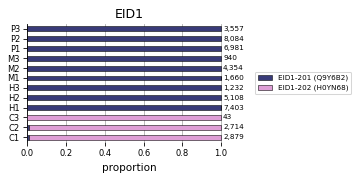

CD63


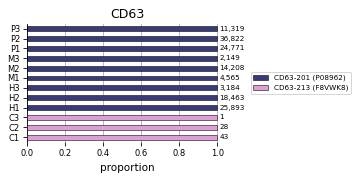

SKP1


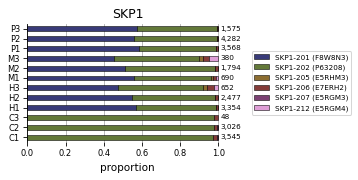

DOCK10


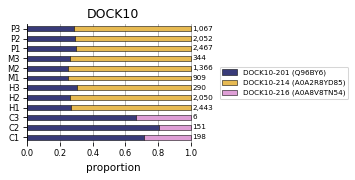

IRF1


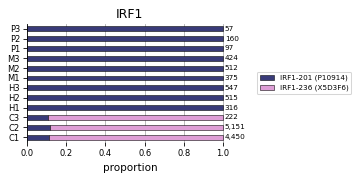

YWHAZ


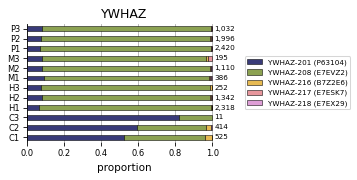

CHRNB1


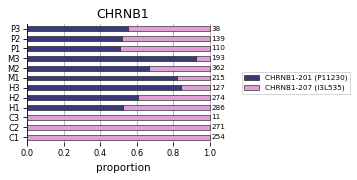

REL


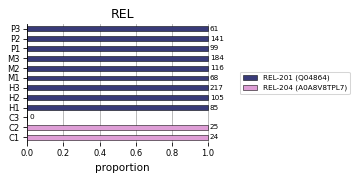

MX1


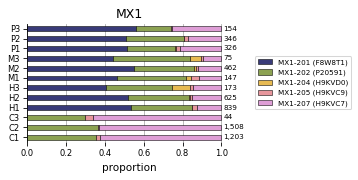

IL6


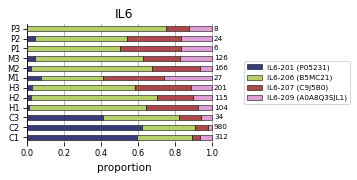

DOCK5


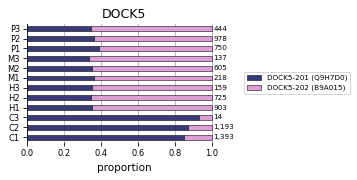

In [49]:
plot_df = pdf.copy()

clusters = ['C1', 'C2', 'C3', 'H1', 'H2', 'H3', 'M1', 'M2', 'M3', 'P1', 'P2', 'P3']
cols = [x + '_pct' for x in clusters]

genes_of_interest = ['EID1', 'CD63', 'SKP1', 'DOCK10', 'IRF1', 'YWHAZ', 'CHRNB1', 'REL', 'MX1', 'IL6', 'DOCK5',]

genes_of_interest = [g for g in genes_of_interest if g in plot_df['gene_name'].unique()]
print(len(genes_of_interest))


for gene in genes_of_interest:
    print(gene)

    gene_df = plot_df[plot_df['gene_name'] == gene].reset_index()
    gene_df = gene_df[gene_df['uniprot'].notna()]

    # Option 1: using np.where
    gene_df['annotation'] = (
        gene_df['transcript_name']
        + np.where(
            gene_df['uniprot'].notna(),
            ' (' + gene_df['uniprot'] + ')',
            ''
        )
    )
    
    tmp = gene_df.set_index('annotation').copy()
    tmp = tmp[cols]
    tmp.columns = [x.replace("_pct", "") for x in tmp.columns]
    
    col_sums = tmp.sum(axis=0)
    col_sums[col_sums == 0] = 1
    
    tmp = tmp.div(col_sums, axis=1)
    
    
    cluster_totals = gene_df[clusters].sum(axis=0)

    plt.rcParams['figure.dpi'] = 75
    plt.rcParams['figure.figsize'] = 5, 2.5

    # 1) Plot figure without legend
    fig1, ax1 = plt.subplots()
    tmp.T.plot(
        kind='barh',
        stacked=True,
        ec='k',
        zorder=10,
        width=0.5,
        linewidth=0.5,
        cmap='tab20b',
        ax=ax1
    )
    ax1.grid(axis='x', zorder=0)
    ax1.set_xlabel("proportion")
    ax1.tick_params(axis='both', labelsize=8)
    sns.move_legend(
        ax1,
        loc='center left',
        title="",
        bbox_to_anchor=(1.1, 0.5),
        fontsize='x-small',
    )
    ax1.set_title(gene)
    sns.despine(bottom=True)
    
    for i, cluster in enumerate(tmp.columns):
        bar_total_proportion = tmp[cluster].sum()
        count = cluster_totals[cluster]
        yloc = i
        ax1.text(bar_total_proportion + 0.01, yloc, f'{int(count):,}',
                 va='center', ha='left', fontsize=7, color='black')
    
    plt.tight_layout()
    plt.show()

#

In [32]:
# adata.obsm["X_umap"] = adata.obs[["UMAP 1", "UMAP 2"]].to_numpy()

# adata.var.set_index('transcript_name', inplace=True)

layer_name= 'log_norm'

if sp.issparse(adata.layers[layer_name]):
    adata.layers[layer_name].data = adata.layers[layer_name].data.astype("float32")
else:
    adata.layers[layer_name] = adata.layers[layer_name].astype("float32")

adata

AnnData object with n_obs × n_vars = 16367 × 51242
    obs: 'dataset', 'n_reads', 'n_transcripts', 'UMAP 1', 'UMAP 2', 'cluster', 'pooled_condition'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB', 'n_counts', 'n_cells'
    uns: 'log1p'
    obsm: 'X_umap'
    layers: 'counts', 'log_norm'

In [40]:
adata.var['transcript_name'] = adata.var.index
adata.var.head()

,gene_id,gene_name,gene_type,transcript_type,Chromosome,Start,End,transcript_id,UniProtKB,n_counts,n_cells,transcript_name
transcript_name,,,,,,,,,,,,
ARF5-201,ENSG00000004059,ARF5,protein_coding,protein_coding,chr7,127588410,127591700,ENST00000000233,P84085,15182.0,9091,ARF5-201
M6PR-201,ENSG00000003056,M6PR,protein_coding,protein_coding,chr12,8940360,8949645,ENST00000000412,P20645,4602.0,3871,M6PR-201
ESRRA-201,ENSG00000173153,ESRRA,protein_coding,protein_coding,chr11,64305523,64316743,ENST00000000442,P11474,225.0,220,ESRRA-201
FKBP4-201,ENSG00000004478,FKBP4,protein_coding,protein_coding,chr12,2794969,2805423,ENST00000001008,Q02790,2906.0,2531,FKBP4-201
NDUFAF7-201,ENSG00000003509,NDUFAF7,protein_coding,protein_coding,chr2,37231657,37249160,ENST00000002125,Q7L592,490.0,478,NDUFAF7-201


In [41]:
def get_transcripts(query, adata=adata):

    df = adata.var[adata.var['gene_name'] == query].copy()

    columns = [
        'gene_name',
        'gene_type',
        'transcript_name',
        'transcript_type',
        'UniProtKB',
    ]

    df = df[columns]

    return df

gene_name      gene_type transcript_name transcript_type UniProtKB
     RARB protein_coding        RARB-201  protein_coding    P10826
     RARB protein_coding        RARB-205  protein_coding       NaN


ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not array([<cupyx.scipy.sparse._csr.csr_matrix object at 0x1533bc66ced0>],
      dtype=object)

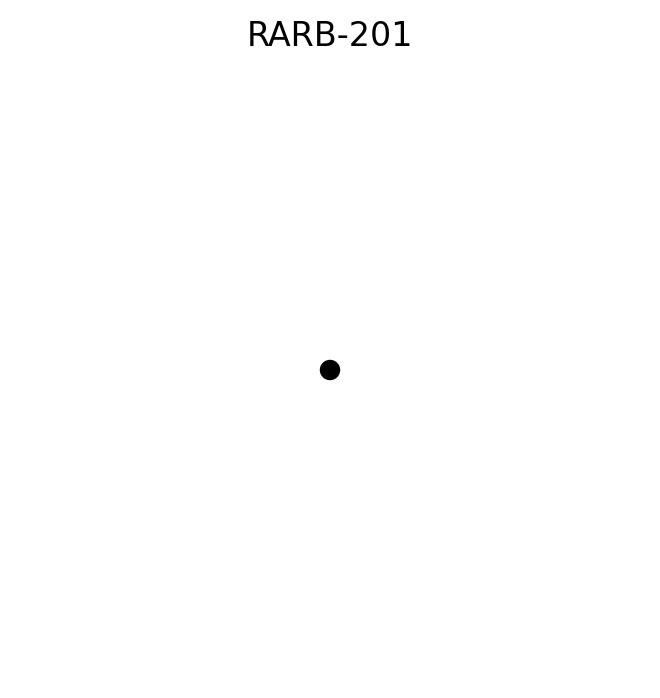

In [44]:
query = 'RARB'
label_df = get_transcripts(query)
print(label_df.to_string(index=False))

color = label_df.index.to_list()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    ncols=4,
    sort_order=True,
    color='RARB-201',
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    cmap='magma',
    colorbar_loc=None,
    frameon=False,
    layer='counts',
)

In [46]:
color = ['RARB-201', 'RARB-205']


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    ncols=3,
    sort_order=True,
    color=color,
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    cmap='magma',
    # colorbar_loc=None,
    frameon=False,
    # layer='log_norm',
)

AttributeError: 'list' object has no attribute 'to_list'

In [25]:
select = [
    'PICK1', 'RFX7', 'SALL1', 'SOX5', 'ZNF520', 
    'ZNF343', 'FOXP2', 'KLF4', 'SP140', 'RARB',
    'SOX6', 'TCF7L2', 'GPANK1', 'TIGD7', 'TRIM69',
    'FOSB', 'IKZF4', 'LHX9', 'NR1H3', 'TCF3', 'YWHAZ',
    'ZNF616', 'AEBP2', 'MIOS', 'NCOA2', 'NNT', 'PKM',
    'SMAD3', 'SMAD6', 'TRIB2', 'ZFP90', 'CNOT3', 'CPEB1',
    'EPAS1', 'ETV4', 'HDAC2', 'IRF1', 'MAPK1', 'MEF2C',
    'MZF1', 'NFIX', 'NR1H3', 'PRDM15', 'RUNX2', 'TP53',
    'TRIM28', 'ZNF232', 'ZNF358',
]

databases = [
    "GO_Biological_Process_2025",
    "Reactome_Pathways_2024",
    "KEGG_2021_Human",
    "WikiPathways_2024_Human",
    'MSigDB_Hallmark_2020',
    'BioPlanet_2019',
    'Panther_2016',
    'CellMarker_2024',
    'PanglaoDB_Augmented_2021',
]

# pd.set_option('display.max_colwidth', None)



n_terms = 5
alpha = 0.05

for database in databases:
    print(f"Running Enrichment with database: {database}...")

    
    enr = gget.enrichr(
        select,
        database=database,
        save=False,
    )

    
    display(enr[['path_name', 'overlapping_genes', 'adj_p_val']].head())
    print("------------------------------------------------------")

21:31:29 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


Running Enrichment with database: GO_Biological_Process_2025...


,path_name,overlapping_genes,adj_p_val
0,Regulation of Transcription by RNA Polymerase II (GO:0006357),"[ZNF232, HDAC2, NFIX, EPAS1, SP140, PRDM15, IKZF4, SALL1, SOX6, SOX5, ZNF343, TCF7L2, NCOA2, MEF2C, SMAD3, NR1H3, KLF4, SMAD6, YWHAZ, ETV4, FOXP2, ZFP90, RUNX2, PKM, AEBP2, RFX7, ZNF616, IRF1, RARB, FOSB, ZNF358, MZF1, TP53, LHX9]",3.089714e-19
1,Regulation of DNA-templated Transcription (GO:0006355),"[ZNF232, HDAC2, NFIX, EPAS1, SP140, PRDM15, IKZF4, SALL1, TRIM28, SOX6, SOX5, ZNF343, TCF7L2, NCOA2, MEF2C, SMAD3, NR1H3, KLF4, SMAD6, ETV4, FOXP2, ZFP90, RUNX2, AEBP2, RFX7, ZNF616, IRF1, FOSB, ZNF358, MZF1, TP53, LHX9]",1.007500e-17
2,Positive Regulation of DNA-templated Transcription (GO:0045893),"[TCF7L2, NCOA2, HDAC2, MEF2C, SMAD3, NFIX, EPAS1, PRDM15, NR1H3, KLF4, ETV4, ZFP90, RUNX2, SALL1, PKM, TRIM28, RFX7, IRF1, RARB, MZF1, TP53]",6.228301e-11
3,Positive Regulation of Transcription by RNA Polymerase II (GO:0045944),"[TCF7L2, NCOA2, HDAC2, MEF2C, SMAD3, NFIX, EPAS1, PRDM15, NR1H3, KLF4, ETV4, RUNX2, SALL1, PKM, RFX7, IRF1, RARB, MZF1, TP53]",6.228301e-11
4,Negative Regulation of DNA-templated Transcription (GO:0045892),"[TCF7L2, HDAC2, MEF2C, SMAD3, NFIX, NR1H3, KLF4, YWHAZ, FOXP2, IKZF4, RUNX2, SALL1, TRIM28, IRF1, RARB, FOSB, MZF1, TP53, LHX9]",7.510357e-11


21:31:29 - INFO - Performing Enrichr analysis using database Reactome_Pathways_2024.


------------------------------------------------------
Running Enrichment with database: Reactome_Pathways_2024...


...

,path_name,overlapping_genes,adj_p_val
0,Embryonic Stem Cell Undefined Human,"[TRIM28, CNOT3, TCF3, KLF4]",0.000831
1,B Cell Lymph Human,"[RFX7, TCF3, TP53]",0.001774
2,Chondrocyte Bone Mouse,"[SOX6, SOX5]",0.001774
3,Chondrogenic Cell Adipose Tissue Mouse,"[SOX6, SOX5]",0.001774
4,Deep Layer Neuron Cortex Human,"[FOXP2, SOX5]",0.001774


21:31:31 - INFO - Performing Enrichr analysis using database PanglaoDB_Augmented_2021.


------------------------------------------------------
Running Enrichment with database: PanglaoDB_Augmented_2021...


,path_name,overlapping_genes,adj_p_val
0,Embryonic Stem Cells,"[SMAD3, TRIM28, KLF4]",0.354657
1,Chondrocytes,"[SOX6, RUNX2]",0.354657
2,Mesangial Cells,"[NCOA2, MEF2C]",0.354657
3,Endothelial Cells (Aorta),"[EPAS1, SMAD6]",0.354657
4,Adipocytes,"[EPAS1, NR1H3]",0.354657


------------------------------------------------------


In [26]:
# enr = gget.enrichr(
#     select,
#     database=database,
#     save=False,
# )

enr = gget.enrichr(select, "GO_Biological_Process_2025", save=False)

display(enr[['path_name', 'overlapping_genes', 'adj_p_val']].head(15))


21:36:25 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


,path_name,overlapping_genes,adj_p_val
0,Regulation of Transcription by RNA Polymerase II (GO:0006357),"[ZNF232, HDAC2, NFIX, EPAS1, SP140, PRDM15, IKZF4, SALL1, SOX6, SOX5, ZNF343, TCF7L2, NCOA2, MEF2C, SMAD3, NR1H3, KLF4, SMAD6, YWHAZ, ETV4, FOXP2, ZFP90, RUNX2, PKM, AEBP2, RFX7, ZNF616, IRF1, RARB, FOSB, ZNF358, MZF1, TP53, LHX9]",3.089714e-19
1,Regulation of DNA-templated Transcription (GO:0006355),"[ZNF232, HDAC2, NFIX, EPAS1, SP140, PRDM15, IKZF4, SALL1, TRIM28, SOX6, SOX5, ZNF343, TCF7L2, NCOA2, MEF2C, SMAD3, NR1H3, KLF4, SMAD6, ETV4, FOXP2, ZFP90, RUNX2, AEBP2, RFX7, ZNF616, IRF1, FOSB, ZNF358, MZF1, TP53, LHX9]",1.007500e-17
2,Positive Regulation of DNA-templated Transcription (GO:0045893),"[TCF7L2, NCOA2, HDAC2, MEF2C, SMAD3, NFIX, EPAS1, PRDM15, NR1H3, KLF4, ETV4, ZFP90, RUNX2, SALL1, PKM, TRIM28, RFX7, IRF1, RARB, MZF1, TP53]",6.228301e-11
3,Positive Regulation of Transcription by RNA Polymerase II (GO:0045944),"[TCF7L2, NCOA2, HDAC2, MEF2C, SMAD3, NFIX, EPAS1, PRDM15, NR1H3, KLF4, ETV4, RUNX2, SALL1, PKM, RFX7, IRF1, RARB, MZF1, TP53]",6.228301e-11
4,Negative Regulation of DNA-templated Transcription (GO:0045892),"[TCF7L2, HDAC2, MEF2C, SMAD3, NFIX, NR1H3, KLF4, YWHAZ, FOXP2, IKZF4, RUNX2, SALL1, TRIM28, IRF1, RARB, FOSB, MZF1, TP53, LHX9]",7.510357e-11
5,Positive Regulation of RNA Biosynthetic Process (GO:1902680),"[TCF7L2, HDAC2, MEF2C, SALL1, SMAD3, TRIM28, IRF1, NR1H3, KLF4, TP53, ZFP90, RUNX2]",6.238178e-07
6,Negative Regulation of RNA Biosynthetic Process (GO:1902679),"[TCF7L2, HDAC2, SALL1, TRIM28, IRF1, KLF4, TP53, FOXP2, IKZF4, LHX9, RUNX2]",1.012499e-06
7,Negative Regulation of Transcription by RNA Polymerase II (GO:0000122),"[TCF7L2, HDAC2, MEF2C, SMAD3, NFIX, NR1H3, KLF4, YWHAZ, SALL1, RARB, FOSB, MZF1, TP53]",1.012499e-06
8,Positive Regulation of Multicellular Organismal Process (GO:0051240),"[TCF7L2, NCOA2, HDAC2, SMAD3, EPAS1, CNOT3, SOX6, ETV4, SOX5]",3.647552e-05
9,Chondrocyte Differentiation (GO:0002062),"[MEF2C, SOX6, RUNX2, SOX5]",7.204749e-05
